# Figure variants

**kmax checks** (per-stat / joint FoB & FoM for top-model and $k{=}3$ ensemble; joint $k_\mathrm{max}$ contours). Joint $k_\mathrm{max}$: shared cut if $\le 0.25$; for $>0.25$, $k_\mathrm{max}^{P_\mathrm{gg}}=k_\mathrm{max}$ with $k_\mathrm{max}^{B}=k_\mathrm{max}^{P_\mathrm{gm}}=0.25$. FoM: marginal (overall), **3D**+$\mathbf{full}$ combined panels. Also **kp0.35 contours** (top model + ensemble) for SHAMe and CV mean, plus **top-5 by $\ell_\mathrm{val}$** with the $k{=}3$ ensemble (full combo).


In [11]:
import sys
import csv
import pickle
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from scipy.stats import chi2
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# --- Fiducial config (matches paper figures) ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]
STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B_\mathrm{ggg}$",
    "pgm": r"$P_\mathrm{gm}$",
}

TAGS_KMAX_KPGM = ["_kpgm0.1", "_kpgm0.15", "_kpgm0.2", "_kpgm0.25", "_kpgm0.27", "_kpgm0.32", "_kpgm0.37"]
TAGS_KMAX_KB = ["_kb0.1", "_kb0.15", "_kb0.17", "_kb0.2", "_kb0.25", "_kb0.27", "_kb0.3", "_kb0.32", "_kb0.37"]
# Nominal kmax mask labels; plot x uses pk bin upper edges (kmax_plot_x_pk).
# Joint / overall cut: all stats share k_max if <=0.25; for >0.25, P_gg uses k_max
# while B and P_gm stay at 0.25 (min(k_max, 0.25)).
K_OVERALL = [0.1, 0.15, 0.2, 0.25, 0.27, 0.32, 0.37]
K_OVERALL_CONTOURS = K_OVERALL + [0.4]  # colormap corner plots only
KMAX_PK = 0.35
KMAX_LOOSE = 0.4  # empty mask tag "" = full range; plot at this label (not KMAX_PK)


def get_stat_label_short(statistics):
    return " + ".join(STAT_LABELS_SHORT[s] for s in statistics)


TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_contours = extents.copy()
extents_contours["b1"] = [0.0, 1.0]


def theta_show_sigma8xb1(theta_show):
    i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
    i_b1 = PARAM_NAMES_ZOOM.index("b1")
    return np.array(
        [
            theta_show[PARAM_NAMES_ZOOM.index("omega_cold")],
            theta_show[i_s8],
            theta_show[i_s8] * theta_show[i_b1],
        ],
        dtype=float,
    )


def extents_sigma8xb1(theta_show, extents_phys=None):
    if extents_phys is None:
        extents_phys = extents_contours
    i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
    extents_rp = {k: v for k, v in extents_phys.items() if k != "b1"}
    extents_rp["sigma8_cold_x_b1"] = [
        extents_phys["b1"][0] * theta_show[i_s8],
        extents_phys["b1"][1] * theta_show[i_s8],
    ]
    return extents_rp

FIGSIZE_CORNER = (5, 5)
FONTSIZE_LEGEND = 9
LOC_LEGEND = (1.02, 0.98)
dir_sbi = paths.DIR_RESULTS / "results_sbi"

FIG_DIR = REPO_ROOT / "figures" / "2026-08-19_figure_variants"
OVERWRITE_FIGURES = True
FIG_EXT = "png"


# kmax corner contours: same Ωc window as extents_contours, tighter σ8 / b1
EXTENTS_KMAX_CONTOURS = {
    **extents_contours,
    "sigma8_cold": [0.75, 0.88],
    "b1": [0.35, 0.60],
}


def save_figure(fig, name, ext=FIG_EXT):
    filename = f"{name}.{ext}"
    path = FIG_DIR / filename
    if path.exists() and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {filename}")
        return
    fig.canvas.draw_idle()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight", facecolor="white", edgecolor="none")
    print(f"Saved: {path}")


def setup_fiducial_inference():
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_FID,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_FID,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    return tags_inf, labels, list(COLORS_FID)


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]


def setup_fixed_mean_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary


In [13]:
NBAR_TAGS_SHAME = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
NBAR_LABELS_SHAME = {
    "_nbar0.00011": r"$\bar{n}=1.1\times10^{-4}$",
    "_nbar0.00022": r"$\bar{n}=2.2\times10^{-4}$",
    "_nbar0.00054": r"$\bar{n}=5.4\times10^{-4}$",
}


def setup_shame_test(tag_mock=TAG_MOCK_SHAME):
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' + m for s, m in zip(STATISTICS_ARR_FID, TAGS_MASK_FID)]
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=tag_mock,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, tag_mock)
    theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, param_vary, theta_obs_full[idxs_zoom]


def plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep, theta_show, *,
    extents=None, add_truth=True, save_name=None,
    param_names=None, unreparameterize=True,
    fontsize_legend=FONTSIZE_LEGEND,
    legend_location=None,
    legend_loc=None,
    loc_legend=LOC_LEGEND,
):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print("No samples on disk for fiducial contours")
        for i, k in enumerate(keep):
            if not k:
                print(f"  missing: {sample_fn(tags_inf[i], tags_test[i])}")
        return
    fig = plotter.plot_contours_inf(
        param_names=param_names or PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=None,
        extents=extents or extents_contours,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=fontsize_legend,
        legend_location=legend_location,
        legend_loc=legend_loc,
        loc_legend=loc_legend,
        unreparameterize=unreparameterize,
        add_truth=add_truth,
        show=False,
    )
    if save_name is not None and fig is not None:
        save_figure(fig, save_name)
    plt.show()


In [14]:
import utils_inference as ui
from ensemble_kmax_utils import (
    N_ENSEMBLE_K,
    KP035_CONFIGS,
    load_ensemble_member_samples,
    member_samples_path,
    mixture_sample_equal,
    model_dir,
    tags_mask_fixed_kp_scale_sweep,
)


STAT_COMBOS_SCALE = [
    (["pk", "pgm"], COLORS_FID[1]),
    (["pk", "bispec"], COLORS_FID[2]),
    (["pk", "bispec", "pgm"], COLORS_FID[3]),
]
# CV-mean overall must use noisy/noisebest (same as per-stat via cvmean_test_tag).
# Do not use noiseless _biasshame_p0_n1 — many kmax dirs only have noisebest mean samples.


# k-bin edges for x-axis placement (mask tags stay at nominal kmax labels).
# Pk/Pgm: 32 log bins in [0.01, 0.4]. Bispec: 12 linear bins in [0.01, 0.4].
_K_MIN_STAT = 0.01
_K_MAX_STAT = 0.4
_N_BINS_PK = 32
_N_BINS_BISPEC = 12
K_EDGES_PK = np.logspace(np.log10(_K_MIN_STAT), np.log10(_K_MAX_STAT), _N_BINS_PK + 1)
K_CENTERS_PK = np.sqrt(K_EDGES_PK[:-1] * K_EDGES_PK[1:])
K_EDGES_BISPEC = np.linspace(_K_MIN_STAT, _K_MAX_STAT, _N_BINS_BISPEC + 1)
K_CENTERS_BISPEC = 0.5 * (K_EDGES_BISPEC[:-1] + K_EDGES_BISPEC[1:])


def kmax_label_to_upper_edge(kmax_label, *, family="pk"):
    """Upper edge of the last included bin for a nominal kmax mask label (k_center < label)."""
    kmax = float(kmax_label)
    if family in ("pk", "pgm"):
        centers, edges = K_CENTERS_PK, K_EDGES_PK
    elif family == "bispec":
        centers, edges = K_CENTERS_BISPEC, K_EDGES_BISPEC
    else:
        raise ValueError(f"unknown family={family!r}")
    included = np.where(centers < kmax)[0]
    if included.size == 0:
        return float(edges[0])
    return float(edges[int(included[-1]) + 1])


def kmax_plot_x_pk(kmax_label):
    return kmax_label_to_upper_edge(kmax_label, family="pk")


def kmax_plot_x_bispec(kmax_label):
    return kmax_label_to_upper_edge(kmax_label, family="bispec")

NBAR_TAGS_SCALE = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
NBAR_LABELS = {
    "_nbar0.00011": r"$\bar{n}=1.1\times10^{-4}$",
    "_nbar0.00022": r"$\bar{n}=2.2\times10^{-4}$",
    "_nbar0.00054": r"$\bar{n}=5.4\times10^{-4}$",
}

PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "b1"]
FOB_KEYS = ["omega_m", "sigma8", "b1"]
FOB3_YLABEL = r"FoB($\Omega_m$, $\sigma_8$, $b_1$)"
PARAM_NAMES_FOB_S8XB1 = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
FOB_KEYS_S8XB1 = ["omega_m", "sigma8", "sigma8_x_b1"]
FOB3_YLABEL_S8XB1 = r"FoB($\Omega_m$, $\sigma_8$, $\sigma_8 b_1$)"
_CHI2_PPF_1SIG = 0.682689492137
FOB_RIDGE = 1e-8


def fob_chi2_sqrt_limit(ndims):
    return float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, int(ndims))))


def compute_fob(
    theta_pred_row, cov, param_names, theta_true, param_vary,
    *,
    param_names_fob=None,
    fob_keys=None,
):
    """FoB in physical (ω_c, σ8, b1) by default, or (ω_c, σ8, σ8×b1) reparam space."""
    param_names_fob = list(param_names_fob or PARAM_NAMES_FOB)
    fob_keys = list(fob_keys or FOB_KEYS)
    names = list(param_names)
    tp = np.asarray(theta_pred_row, dtype=float)
    cov_arr = np.asarray(cov, dtype=float)
    theta_true = np.asarray(theta_true, dtype=float)
    use_s8xb1 = "sigma8_cold_x_b1" in param_names_fob

    if use_s8xb1:
        if not ui.has_reparameterized_sigma8_columns(names):
            raise ValueError("FoB(σ8×b1) requires reparameterized samples with sigma8_cold_x_b1")
        theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
        names_rep = list(names_rep)
        true_vec = np.array(
            [float(theta_true_rep[names_rep.index(pn)]) for pn in names], dtype=float,
        )
        true_fob = np.array(
            [true_vec[names.index(pn)] for pn in param_names_fob], dtype=float,
        )
        mu = np.array(
            [float(tp[names.index(pn)]) for pn in param_names_fob], dtype=float,
        )
        idx_fob = [names.index(pn) for pn in param_names_fob]
    else:
        if ui.has_reparameterized_sigma8_columns(names):
            theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
            names_rep = list(names_rep)
            true_aligned = np.array(
                [float(theta_true_rep[names_rep.index(pn)]) for pn in names], dtype=float,
            )
            tp_u, tt_u, cov_u, names_u = ui.unreparameterize_prediction_block(
                tp[None, :], true_aligned[None, :], names, covs_per_sample=cov_arr[None, :, :],
            )
            tp, true_vec, cov_arr, names = tp_u[0], tt_u[0], cov_u[0], list(names_u)
        else:
            names_phys = list(param_vary)
            true_vec = np.array(
                [float(theta_true[names_phys.index(pn)]) for pn in names], dtype=float,
            )
        true_fob = np.array([true_vec[names.index(pn)] for pn in param_names_fob], dtype=float)
        mu = np.array([float(tp[names.index(pn)]) for pn in param_names_fob], dtype=float)
        idx_fob = [names.index(pn) for pn in param_names_fob]

    cov_sub = cov_arr[np.ix_(idx_fob, idx_fob)] + FOB_RIDGE * np.eye(len(idx_fob))
    fob = {}
    for key, i in zip(fob_keys, range(len(fob_keys))):
        sig = np.sqrt(cov_sub[i, i])
        fob[key] = abs(mu[i] - true_fob[i]) / sig if sig > 0 else np.nan
    diff = mu - true_fob
    sign, _logdet = np.linalg.slogdet(cov_sub)
    cov_inv = np.linalg.inv(cov_sub) if sign > 0 else np.linalg.pinv(cov_sub)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff))
    return fob, fob3


def _nbar_shades(hex_base):
    rgb = np.array(mcolors.to_rgb(hex_base))
    return [
        mcolors.to_hex(0.42 * rgb + 0.58 * np.ones(3)),
        mcolors.to_hex(rgb),
        mcolors.to_hex(0.42 * rgb + 0.58 * np.zeros(3)),
    ]


def kmax_kb_numeric(tag_kb):
    """Nominal bispec kmax label from mask tag (paths / missing-point messages)."""
    if tag_kb == "":
        return KMAX_LOOSE  # loose cut = full bispec range, not the fixed Pk kmax
    return float(tag_kb.replace("_kb", ""))


def kmax_kpgm_numeric(tag_kpgm):
    """Nominal PGM kmax label from mask tag (paths / missing-point messages)."""
    if tag_kpgm == "":
        return KMAX_LOOSE
    return float(tag_kpgm.replace("_kpgm", ""))


def kmax_plot_x_kb(tag_kb):
    """Bispec sweep x-position: upper edge of last included bispec k-bin."""
    return kmax_plot_x_bispec(kmax_kb_numeric(tag_kb))


def kmax_plot_x_kpgm(tag_kpgm):
    """PGM sweep x-position: upper edge of last included pk/pgm k-bin."""
    return kmax_plot_x_pk(kmax_kpgm_numeric(tag_kpgm))


def _fixed_kp_mask(statistics_row, *, tag_kb=None, tag_kpgm=None):
    tags = tags_mask_fixed_kp_scale_sweep(
        statistics_row, KMAX_PK, tag_kb=tag_kb, tag_kpgm=tag_kpgm,
    )
    return "".join(tags)


def _top_samples_path(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[statistics_row],
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask],
    )
    tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
    tag_stats = f"_{'_'.join(statistics_row)}"
    if test_mode == "shame":
        tag_test = utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=[tag_stats],
            tags_mask=[tag_mask],
            tag_mock=tag_mock,
            data_mode_test=DATA_MODE_TEST_SHAME,
        )[0]
    elif test_mode == "cvmean":
        from ensemble_kmax_utils import cvmean_test_tag
        tag_test = cvmean_test_tag(statistics_row, tag_mask)
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    fn = dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"
    fn_pn = dir_sbi / f"sbi{tag_inf}" / "param_names.txt"
    if not fn.is_file():
        return None, None, f"missing samples file: {fn}"
    if not fn_pn.is_file():
        return None, None, f"missing param_names file: {fn_pn}"
    return np.load(fn), np.loadtxt(fn_pn, dtype=str), None


def load_top_fob3(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_top_fob3, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_top_fob3, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    if test_mode == "shame":
        theta_phys = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME, tag_mock,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    elif test_mode == "cvmean":
        from generate_config_inference import resolve_test_scenario_tags
        _cv = resolve_test_scenario_tags("fixed_cosmo_shame_mean", "noisy", TAG_PARAMS_TEST_FIXED)
        theta_phys = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED, _cv["tag_biasparams_test"],
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
        if getattr(theta_phys, "ndim", 1) == 2:
            theta_phys = theta_phys[idx_obs]
    else:
        raise ValueError(test_mode)
    _, fob3 = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if fob3 is None or not np.isfinite(fob3):
        return None, f"non-finite FoB3 (mask={tag_mask!r}, mode={test_mode})"
    return fob3, None


def _try_load_top_fob3(
    statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = load_top_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _report_missing_fob3(panel_title, statistics_row, tag_mock, kmax, reasons):
    label = get_stat_label_short(statistics_row)
    detail = "; ".join(reasons) if reasons else "unknown"
    print(
        f"MISSING FoB3 point | panel={panel_title} | stats={label} | "
        f"nbar={tag_mock} | k_max={kmax} | tried: {detail}"
    )


def _sweep_bispec_fob3(
    statistics_row, *, tag_kpgm_fixed="_kpgm0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False, param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"bispec sweep (PGM kmax=0.25 fixed, {test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm_fixed)]
        val, reasons = _try_load_top_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fob3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fob3(
    statistics_row, *, tag_kb_fixed="_kb0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False, param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"PGM sweep (bispec kmax=0.25 fixed, {test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb_fixed)]
        val, reasons = _try_load_top_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fob3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _constant_fob3_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False, param_names_fob=None, fob_keys=None,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
        panel_title = "bispec sweep (constant Pgg+Pgm)"
        kmax = 0.25
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
        panel_title = "PGM sweep (constant Pgg+Bggg)"
        kmax = 0.25
    else:
        return None
    val, reasons = _try_load_top_fob3(
        statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if val is None and report_missing:
        ctx = tag_mock if test_mode == "shame" else test_mode
        _report_missing_fob3(panel_title, statistics_row, ctx, kmax, reasons)
    return val


def plot_scale_fob3_top(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=False,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    ref3 = fob_chi2_sqrt_limit(3)
    load_top_fob3._param_names_fob = param_names_fob
    load_top_fob3._fob_keys = fob_keys
    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5), sharey=True)
    panel_specs = [
        (axes[0], _sweep_bispec_fob3, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True),
        (axes[1], _sweep_pgm_fob3, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for ax, sweep_fn, xlabel, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock in enumerate(tag_mocks):
                c = color_shades[j] if test_mode == "shame" else color
                line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                const_val = _constant_fob3_on_sweep(
                    statistics_row,
                    bispec_sweep=bispec_sweep,
                    test_mode=test_mode,
                    tag_mock=tag_mock,
                    report_missing=report_missing,
                    param_names_fob=param_names_fob,
                    fob_keys=fob_keys,
                ) if test_mode == "shame" else None
                if const_val is not None:
                    ax.axhline(
                        const_val / ref3, color=c, lw=1.2, ls="-", alpha=0.95,
                        label=line_label, zorder=1,
                    )
                    continue
                mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                xs, ys = sweep_fn(
                    statistics_row, test_mode=test_mode, report_missing=report_missing,
                    param_names_fob=param_names_fob, fob_keys=fob_keys, **mock_kw,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order] / ref3
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.set_xlabel(xlabel, fontsize=14)

    axes[0].axvline(kmax_plot_x_bispec(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    axes[1].axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    for ax in axes:
        ax.set_xlim(0.09, 0.39)
        ax.tick_params(labelsize=12)
    ylab = FOB3_YLABEL if ylabel is None else ylabel
    axes[0].set_ylabel(ylab, fontsize=14)
    axes[1].set_ylabel(ylab, fontsize=14)
    axes[0].set_ylim(0.0, 2.5)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


PARAM_NAMES_FOM = ["omega_cold", "sigma8_cold", "b1"]
FOM3_YLABEL = r"FoM($\Omega_m$, $\sigma_8$, $b_1$)"
FOM_FULL_YLABEL = r"FoM(all params)"
FOM_MARG_LABELS = {
    "omega_cold": r"FoM($\Omega_\mathrm{c}$)",
    "sigma8_cold": r"FoM($\sigma_8$)",
    "b1": r"FoM($b_1$)",
}

FOB_MARG_LABELS = {
    "omega_m": r"FoB($\Omega_\mathrm{c}$)",
    "sigma8": r"FoB($\sigma_8$)",
    "b1": r"FoB($b_1$)",
}


def compute_fom_key_block(cov, param_names, theta_pred_row=None):
    """FoM in physical (ω_c, σ8, b1) space; unreparameterizes cov if needed."""
    names = list(param_names)
    cov_arr = np.asarray(cov, dtype=float)
    if ui.has_reparameterized_sigma8_columns(names):
        if theta_pred_row is None:
            raise ValueError("theta_pred_row required to unreparameterize FoM covariance")
        tp = np.asarray(theta_pred_row, dtype=float)
        sigma8 = float(tp[names.index("sigma8_cold")])
        cov_arr = ui.scale_covariance_unreparameterize_approx(cov_arr, names, sigma8)
        _, names = ui.unreparameterize_theta(tp, names)
        names = list(names)
    idx_fom = [names.index(pn) for pn in PARAM_NAMES_FOM]
    cov_sub = cov_arr[np.ix_(idx_fom, idx_fom)]
    fom_marg = {}
    for i, pn in enumerate(PARAM_NAMES_FOM):
        sig = np.sqrt(cov_sub[i, i])
        fom_marg[pn] = 1.0 / sig if sig > 0 else np.nan
    det = np.linalg.det(cov_sub)
    fom_3d = 1.0 / np.sqrt(det) if det > 0 else np.nan
    return fom_marg, float(fom_3d)


def compute_fom_full(cov):
    """FoM = 1/sqrt(det C) over all parameters in the chain covariance."""
    return float(ui.figure_of_merit(np.asarray(cov, dtype=float)))


def load_top_fom_marg(
    statistics_row, tag_mask, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    """Return (marginal FoM for param_name, None) or (None, reason)."""
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    fom_marg, _ = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    val = fom_marg.get(param_name)
    if val is None or not np.isfinite(val):
        return None, f"non-finite FoM({param_name!r}) (mask={tag_mask!r}, mode={test_mode})"
    return float(val), None


def load_top_fom3(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    """Return (fom3, None) on success, or (None, reason) if missing/invalid."""
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    _, fom3 = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    if fom3 is None or not np.isfinite(fom3):
        return None, f"non-finite FoM3 (mask={tag_mask!r}, mode={test_mode})"
    return fom3, None


def load_top_fom_full(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    """Return (full-chain FoM, None) on success, or (None, reason)."""
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    cov = np.cov(samples[:, 0, :].T)
    fom = compute_fom_full(cov)
    if fom is None or not np.isfinite(fom):
        return None, f"non-finite FoM_full (mask={tag_mask!r}, mode={test_mode})"
    return float(fom), None


def _try_load_top_fom(
    statistics_row, mask_candidates, *, kind="3d", test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    loader = load_top_fom3 if kind == "3d" else load_top_fom_full
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = loader(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _try_load_top_fom3(
    statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    return _try_load_top_fom(
        statistics_row, mask_candidates, kind="3d",
        test_mode=test_mode, tag_mock=tag_mock,
    )


def _report_missing_fom3(panel_title, statistics_row, tag_mock, kmax, reasons):
    label = get_stat_label_short(statistics_row)
    detail = "; ".join(reasons) if reasons else "unknown"
    print(
        f"MISSING FoM3 point | panel={panel_title} | stats={label} | "
        f"nbar={tag_mock} | k_max={kmax} | tried: {detail}"
    )


def _sweep_bispec_fom(
    statistics_row, *, kind="3d", tag_kpgm_fixed="_kpgm0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"bispec sweep FoM-{kind} (PGM kmax=0.25 fixed, {test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm_fixed)]
        val, reasons = _try_load_top_fom(
            statistics_row, candidates, kind=kind, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fom3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_bispec_fom3(
    statistics_row, *, tag_kpgm_fixed="_kpgm0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    return _sweep_bispec_fom(
        statistics_row, kind="3d", tag_kpgm_fixed=tag_kpgm_fixed,
        test_mode=test_mode, tag_mock=tag_mock, report_missing=report_missing,
    )


def _sweep_pgm_fom(
    statistics_row, *, kind="3d", tag_kb_fixed="_kb0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"PGM sweep FoM-{kind} (bispec kmax=0.25 fixed, {test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb_fixed)]
        val, reasons = _try_load_top_fom(
            statistics_row, candidates, kind=kind, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fom3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fom3(
    statistics_row, *, tag_kb_fixed="_kb0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    return _sweep_pgm_fom(
        statistics_row, kind="3d", tag_kb_fixed=tag_kb_fixed,
        test_mode=test_mode, tag_mock=tag_mock, report_missing=report_missing,
    )


def _constant_fom_on_sweep(
    statistics_row, *, kind="3d", bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
        panel_title = f"bispec sweep FoM-{kind} (constant Pgg+Pgm)"
        kmax = 0.25
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
        panel_title = f"PGM sweep FoM-{kind} (constant Pgg+Bggg)"
        kmax = 0.25
    else:
        return None
    val, reasons = _try_load_top_fom(
        statistics_row, candidates, kind=kind, test_mode=test_mode, tag_mock=tag_mock,
    )
    if val is None and report_missing:
        ctx = tag_mock if test_mode == "shame" else test_mode
        _report_missing_fom3(panel_title, statistics_row, ctx, kmax, reasons)
    return val


def _constant_fom3_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False,
):
    return _constant_fom_on_sweep(
        statistics_row, kind="3d", bispec_sweep=bispec_sweep,
        test_mode=test_mode, tag_mock=tag_mock, report_missing=report_missing,
    )


def plot_scale_fom_top(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=False,
):
    """Per-stat FoM vs k_max: 2x2 (rows=B/Pgm sweep, cols=FoM3 / FoM-all)."""
    kinds = ("3d", "full")
    ylabels = (FOM3_YLABEL, FOM_FULL_YLABEL)
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex="col")
    sweep_specs = [
        (_sweep_bispec_fom, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True, kmax_plot_x_bispec(0.25)),
        (_sweep_pgm_fom, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False, kmax_plot_x_pk(0.25)),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for i_row, (sweep_fn, xlabel, bispec_sweep, vline_x) in enumerate(sweep_specs):
        for i_col, (kind, ylab) in enumerate(zip(kinds, ylabels)):
            ax = axes[i_row, i_col]
            for statistics_row, color in STAT_COMBOS_SCALE:
                label = get_stat_label_short(statistics_row)
                color_shades = _nbar_shades(color)
                for j, tag_mock in enumerate(tag_mocks):
                    c = color_shades[j] if test_mode == "shame" else color
                    line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                    const_val = (
                        _constant_fom_on_sweep(
                            statistics_row, kind=kind, bispec_sweep=bispec_sweep,
                            test_mode=test_mode, tag_mock=tag_mock,
                            report_missing=report_missing,
                        ) if test_mode == "shame" else None
                    )
                    if const_val is not None:
                        ax.axhline(
                            const_val, color=c, lw=1.2, ls="-", alpha=0.95,
                            label=line_label, zorder=1,
                        )
                        continue
                    mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                    xs, ys = sweep_fn(
                        statistics_row, kind=kind, test_mode=test_mode,
                        report_missing=report_missing, **mock_kw,
                    )
                    if xs.size == 0:
                        continue
                    order = np.argsort(xs)
                    xs, ys = xs[order], ys[order]
                    ax.plot(
                        xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                        label=line_label, zorder=2 + j,
                    )
            ax.axvline(vline_x, color="0.6", ls="--", lw=1.0, zorder=0)
            ax.set_xlim(0.09, 0.39)
            ax.set_yscale("log")
            ax.tick_params(labelsize=11)
            ax.set_ylabel(ylab, fontsize=12)
            if i_row == 1:
                ax.set_xlabel(xlabel, fontsize=13)
    _ensemble_scale_legend(axes[0, 0], test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_fom3_top(**kwargs):
    return plot_scale_fom_top(**kwargs)

def _ensemble_scale_legend(axes, *, test_mode, nbar_tags):
    from matplotlib.lines import Line2D

    ax = axes[0] if hasattr(axes, "__getitem__") else axes
    handles_stat, labels_stat = ax.get_legend_handles_labels()
    leg1 = ax.legend(
        handles_stat, labels_stat, fontsize=9, loc="upper left", labelcolor="black",
    )
    if test_mode == "shame":
        ax.add_artist(leg1)
        nbar_legend_shades = _nbar_shades("0.25")
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j, _t in enumerate(nbar_tags)
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        loc_nbar = "upper right" if "FoB" in ax.get_ylabel() else "lower right"
        ax.legend(
            handles_nbar, labels_nbar, fontsize=9, loc=loc_nbar, labelcolor="black",
            title=r"$\bar n$", title_fontsize=9,
        )


KMAX_OVERALL_XLABEL = (
    r"$k_\mathrm{max}$ "
    r"($=k_\mathrm{max}^{P_\mathrm{gg}}$; "
    r"$k_\mathrm{max}^{B}=k_\mathrm{max}^{P_\mathrm{gm}}=\min(k_\mathrm{max},\,0.25)$)"
)
KMAX_OVERALL_CBAR_LABEL = KMAX_OVERALL_XLABEL
STAT_COMBOS_OVERALL = [
    (statistics_row, COLORS_FID[i])
    for i, statistics_row in enumerate(STATISTICS_ARR_FID)
]



def _overall_kmax_tag_test(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tags_inf_k, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[statistics_row],
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask],
    )
    tag_inf = tags_inf_k[0] + TAG_INF_BEST_SUFFIX
    tag_stats = f"_{'_'.join(statistics_row)}"
    if test_mode == "shame":
        tag_test = utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=[tag_stats],
            tags_mask=[tag_mask],
            tag_mock=tag_mock,
            data_mode_test=DATA_MODE_TEST_SHAME,
        )[0]
    elif test_mode == "cvmean":
        from ensemble_kmax_utils import cvmean_test_tag
        tag_test = cvmean_test_tag(statistics_row, tag_mask)
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    return tag_inf, tag_test


def _overall_kmax_samples_path(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tag_inf, tag_test = _overall_kmax_tag_test(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    fn = dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"
    fn_pn = dir_sbi / f"sbi{tag_inf}" / "param_names.txt"
    if not fn.is_file():
        return None, None, f"missing samples file: {fn}"
    if not fn_pn.is_file():
        return None, None, f"missing param_names file: {fn_pn}"
    return np.load(fn), np.loadtxt(fn_pn, dtype=str), None


def _theta_true_overall_kmax(*, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    cosmo_vary, bias_vary, _ = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    if test_mode == "shame":
        return data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME,
            tag_mock,
            cosmo_param_names_vary=cosmo_vary,
            bias_param_names_vary=bias_vary,
        )
    if test_mode == "cvmean":
        from generate_config_inference import resolve_test_scenario_tags
        _cv = resolve_test_scenario_tags("fixed_cosmo_shame_mean", "noisy", TAG_PARAMS_TEST_FIXED)
        theta = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED,
            _cv["tag_biasparams_test"],
            cosmo_param_names_vary=cosmo_vary,
            bias_param_names_vary=bias_vary,
        )
        return theta[idx_obs] if getattr(theta, "ndim", 1) == 2 else theta
    raise ValueError(f"unknown test_mode={test_mode!r}")


def load_overall_kmax_fob3(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_overall_kmax_fob3, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_overall_kmax_fob3, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    samples, param_names, path_err = _overall_kmax_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"all-NaN samples ({ctx})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    theta_phys = _theta_true_overall_kmax(test_mode=test_mode, tag_mock=tag_mock)
    _, fob3 = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if fob3 is None or not np.isfinite(fob3):
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"non-finite FoB3 ({ctx})"
    return fob3, None


def load_overall_kmax_fob_marg(
    statistics_row, tag_mask, fob_key, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_overall_kmax_fob_marg, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_overall_kmax_fob_marg, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    samples, param_names, path_err = _overall_kmax_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"all-NaN samples ({ctx})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    theta_phys = _theta_true_overall_kmax(test_mode=test_mode, tag_mock=tag_mock)
    fob, _ = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    val = fob.get(fob_key) if fob else None
    if val is None or not np.isfinite(val):
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"non-finite FoB({fob_key!r}) ({ctx})"
    return float(val), None


def load_overall_kmax_fom_marg(
    statistics_row, tag_mask, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    samples, param_names, path_err = _overall_kmax_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"all-NaN samples ({ctx})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    fom_marg, _ = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    val = fom_marg.get(param_name)
    if val is None or not np.isfinite(val):
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"non-finite FoM({param_name!r}) ({ctx})"
    return float(val), None


def overall_k_mask(statistics_row, k):
    """Joined tags_mask for joint overall scale cut at k.

    For k <= 0.25 every statistic uses k; for k > 0.25, Pk uses k while
    bispec and Pgm are capped at 0.25.
    """
    k_other = k if k <= 0.25 else 0.25
    parts = []
    for s in statistics_row:
        if s == "pk":
            parts.append(f"_kp{k}")
        elif s == "bispec":
            parts.append(f"_kb{k_other}")
        elif s == "pgm":
            parts.append(f"_kpgm{k_other}")
        else:
            raise ValueError(s)
    return "".join(parts)


def _sweep_overall_fob3(
    statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
    param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"overall kmax ({test_mode})"
    ctx_label = tag_mock if test_mode == "shame" else test_mode
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_overall_kmax_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, ctx_label, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_overall_fob_marg(
    statistics_row, fob_key, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
    param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"overall kmax ({fob_key}, {test_mode})"
    ctx_label = tag_mock if test_mode == "shame" else test_mode
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_overall_kmax_fob_marg(
            statistics_row, tag_mask, fob_key, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, ctx_label, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_overall_fom_marg(
    statistics_row, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"overall kmax ({param_name}, {test_mode})"
    ctx_label = tag_mock if test_mode == "shame" else test_mode
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_overall_kmax_fom_marg(
            statistics_row, tag_mask, param_name,
            test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is None:
            if report_missing:
                _report_missing_fom3(panel_title, statistics_row, ctx_label, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_overall_fom(
    statistics_row, *, kind="3d", test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"overall kmax FoM-{kind} ({test_mode})"
    ctx_label = tag_mock if test_mode == "shame" else test_mode
    loader = load_top_fom3 if kind == "3d" else load_top_fom_full
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = loader(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is None:
            if report_missing:
                _report_missing_fom3(panel_title, statistics_row, ctx_label, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_overall_fom3(
    statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    return _sweep_overall_fom(
        statistics_row, kind="3d", test_mode=test_mode, tag_mock=tag_mock,
        report_missing=report_missing,
    )


def plot_scale_overall_kmax_fob3(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    nbar_tags=None,
    save_name=None,
    report_missing=False,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    """Joint overall k_max FoB vs k — one panel per parameter (not combined FoB3)."""
    from matplotlib.lines import Line2D

    param_names_fob = list(param_names_fob or PARAM_NAMES_FOB)
    fob_keys = list(fob_keys or FOB_KEYS)
    load_overall_kmax_fob_marg._param_names_fob = param_names_fob
    load_overall_kmax_fob_marg._fob_keys = fob_keys
    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

    if test_mode == "cvmean":
        nbar_tags = [None]
        nbar_legend_shades = None
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        nbar_legend_shades = _nbar_shades("0.25")
        title = None

    for ax, fob_key in zip(axes, fob_keys):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = tag_mock
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _sweep_overall_fob_marg(
                    statistics_row, fob_key, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                    param_names_fob=param_names_fob, fob_keys=fob_keys,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.axhline(1.0, color="0.75", ls=":", lw=1.0, zorder=0)
        ylab = FOB_MARG_LABELS.get(fob_key, f"FoB({fob_key})")
        if ylabel is not None and len(fob_keys) == 1:
            ylab = ylabel
        ax.set_ylabel(ylab, fontsize=14)
        ax.set_ylim(0.0, 2.5)
        ax.tick_params(labelsize=12)

    axes[-1].set_xlim(0.09, 0.39)
    axes[-1].set_xlabel(KMAX_OVERALL_XLABEL, fontsize=12)
    if title is not None:
        axes[0].set_title(title, fontsize=13)

    handles_stat, labels_stat = axes[0].get_legend_handles_labels()
    leg1 = axes[0].legend(
        handles_stat, labels_stat, fontsize=9, loc="upper left", labelcolor="black",
    )
    axes[0].add_artist(leg1)
    if nbar_legend_shades is not None:
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j in range(len(nbar_tags))
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        axes[0].legend(
            handles_nbar, labels_nbar, fontsize=9, loc="upper right", labelcolor="black",
            title=r"$\bar n$", title_fontsize=9,
        )
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()




def plot_scale_overall_kmax_fob3_shame_nbars(**kwargs):
    return plot_scale_overall_kmax_fob3(test_mode="shame", **kwargs)


def plot_scale_overall_kmax_fom3(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    nbar_tags=None,
    save_name=None,
    report_missing=False,
):
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

    if test_mode == "cvmean":
        nbar_tags = [None]
        nbar_legend_shades = None
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        nbar_legend_shades = _nbar_shades("0.25")
        title = None

    for ax, param_name in zip(axes, PARAM_NAMES_FOM):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = tag_mock
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _sweep_overall_fom_marg(
                    statistics_row, param_name, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.set_ylabel(FOM_MARG_LABELS[param_name], fontsize=14)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)

    axes[-1].set_xlim(0.09, 0.39)
    axes[-1].set_xlabel(KMAX_OVERALL_XLABEL, fontsize=12)
    if title is not None:
        axes[0].set_title(title, fontsize=13)

    handles_stat, labels_stat = axes[0].get_legend_handles_labels()
    leg1 = axes[0].legend(
        handles_stat, labels_stat, fontsize=9, loc="upper left", labelcolor="black",
    )
    if nbar_legend_shades is not None:
        axes[0].add_artist(leg1)
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j, _t in enumerate(nbar_tags)
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        axes[0].legend(
            handles_nbar, labels_nbar, fontsize=9, loc="lower right", labelcolor="black",
            title=r"$\bar n$", title_fontsize=9,
        )
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_overall_kmax_fom3_shame_nbars(**kwargs):
    return plot_scale_overall_kmax_fom3(test_mode="shame", **kwargs)


def plot_scale_overall_kmax_fom_joint(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    nbar_tags=None,
    save_name=None,
    report_missing=False,
):
    """Overall k_max FoM: 2 panels — FoM3 (key params) and FoM-all (full chain)."""
    from matplotlib.lines import Line2D

    kinds = ("3d", "full")
    ylabels = (FOM3_YLABEL, FOM_FULL_YLABEL)
    fig, axes = plt.subplots(2, 1, figsize=(7, 7.0), sharex=True)

    if test_mode == "cvmean":
        nbar_tags = [None]
        nbar_legend_shades = None
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        nbar_legend_shades = _nbar_shades("0.25")
        title = None

    for ax, kind, ylab in zip(axes, kinds, ylabels):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = tag_mock
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _sweep_overall_fom(
                    statistics_row, kind=kind, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.set_xlim(0.09, 0.39)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)
        ax.set_ylabel(ylab, fontsize=14)

    axes[-1].set_xlabel(KMAX_OVERALL_XLABEL, fontsize=12)
    if title is not None:
        axes[0].set_title(title, fontsize=13)

    handles_stat, labels_stat = axes[0].get_legend_handles_labels()
    leg1 = axes[0].legend(
        handles_stat, labels_stat, fontsize=9, loc="upper left", labelcolor="black",
    )
    if nbar_legend_shades is not None:
        axes[0].add_artist(leg1)
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j, _t in enumerate(nbar_tags)
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        axes[0].legend(
            handles_nbar, labels_nbar, fontsize=9, loc="lower right", labelcolor="black",
            title=r"$\bar n$", title_fontsize=9,
        )
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.14)
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


STATISTICS_OVERALL_FULL = ["pk", "bispec", "pgm"]


def pp_style_colors_kmax(k_values):
    """Reversed plasma colors for overall k_max sweep (low k → high k).

    Colormap starts at 20% into plasma_r so the lowest-k contour is not the
    extreme yellow end of the scale.
    """
    k_arr = np.asarray(k_values, dtype=float)
    base = plt.cm.plasma_r
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "plasma_r_from20", base(np.linspace(0.20, 1.0, 256))
    )
    norm = mcolors.Normalize(vmin=float(k_arr.min()), vmax=float(k_arr.max()))
    colors = [mcolors.to_hex(cmap(norm(k))) for k in k_arr]
    return colors, cmap, norm


def add_kmax_colorbar(fig, cmap, norm, *, label=None):
    if label is None:
        label = KMAX_OVERALL_CBAR_LABEL
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.88, 0.35, 0.025, 0.50])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_label(label, fontsize=FONTSIZE_LEGEND)
    cb.ax.tick_params(labelsize=FONTSIZE_LEGEND - 1)
    return cb


def _overall_kmax_contour_tag_test(statistics_row, k, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tag_mask = overall_k_mask(statistics_row, k)
    tag_inf, tag_test = _overall_kmax_tag_test(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    return tag_inf, tag_test, tag_mask


def _theta_show_overall_kmax_contours(*, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    if test_mode == "shame":
        theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, tag_mock)
        theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    elif test_mode == "cvmean":
        theta_obs = _theta_true_overall_kmax(test_mode="cvmean")
        theta_obs_full = np.array([theta_obs[param_vary.index(pn)] for pn in param_vary])
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return theta_obs_full[idxs_zoom]


def plot_overall_kmax_contours_full_combo(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    k_values=None,
    save_name=None,
    report_missing=False,
):
    """Corner contours for pk+bispec+pgm vs joint overall k_max; colorbar encodes k."""
    k_values = list(k_values or K_OVERALL_CONTOURS)
    statistics_row = STATISTICS_OVERALL_FULL
    theta_show = _theta_show_overall_kmax_contours(test_mode=test_mode, tag_mock=tag_mock)
    extents_use = EXTENTS_KMAX_CONTOURS

    tags_inf, tags_test, k_present = [], [], []
    missing = []
    for k in k_values:
        tag_inf, tag_test, tag_mask = _overall_kmax_contour_tag_test(
            statistics_row, k, test_mode=test_mode, tag_mock=tag_mock,
        )
        if not sample_fn(tag_inf, tag_test).is_file():
            missing.append((k, tag_mask, tag_inf, tag_test))
            if report_missing:
                print(f"MISSING overall-k contour | {test_mode} | k={k} | {sample_fn(tag_inf, tag_test)}")
            continue
        tags_inf.append(tag_inf)
        tags_test.append(tag_test)
        k_present.append(k)

    if not tags_inf:
        print(f"No samples for overall k_max contour plot ({test_mode})")
        return

    colors, cmap, norm = pp_style_colors_kmax(k_present)
    n = len(tags_inf)
    if test_mode == "shame":
        subtitle = f"SHAMe OOD {NBAR_LABELS.get(tag_mock, tag_mock)}"
    elif test_mode == "cvmean":
        subtitle = "cosmic-variance mean"
    else:
        subtitle = test_mode
    title = f"{get_stat_label_short(statistics_row)}, {subtitle}"
    fig = plotter.plot_contours_inf(
        param_names=list(PARAM_NAMES_ZOOM),
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * n,
        tags_inf=tags_inf,
        tags_test=tags_test,
        colors=colors,
        labels=[rf"$k_\mathrm{{max}}={k}$" for k in k_present],
        title=title,
        extents=extents_use,
        figsize=(5.8, 5.8),
        fontsize_legend=FONTSIZE_LEGEND,
        unreparameterize=True,
        show_label_in_legend=[False] * n,
        legend_location=None,
        loc_legend=None,
        show=False,
    )
    if fig is None:
        return
    add_kmax_colorbar(fig, cmap, norm)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()
    if missing and report_missing:
        print(f"Skipped {len(missing)} k points (missing samples)")


ENSEMBLE_SUFFIX = f"_ensemble_top{N_ENSEMBLE_K}"


def _ensemble_samples_path(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, n_total=5000,
):
    samples, missing = load_ensemble_member_samples(
        statistics_row,
        tag_mask,
        test_mode=test_mode,
        tag_mock=tag_mock,
        k_members=N_ENSEMBLE_K,
        n_total=n_total,
    )
    if samples is None:
        return None, None, "; ".join(missing)
    d0 = model_dir(statistics_row, tag_mask, 0)
    fn_pn = d0 / "param_names.txt"
    if not fn_pn.is_file():
        return None, None, f"missing param_names: {fn_pn}"
    return samples, np.loadtxt(fn_pn, dtype=str), None


def _ensemble_theta_cov(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    samples, param_names, path_err = _ensemble_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, None, None, path_err
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    return theta_pred, cov, param_names, None


def load_ensemble_fob3(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_ensemble_fob3, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_ensemble_fob3, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    if test_mode == "shame":
        theta_phys = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME, tag_mock,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    elif test_mode == "cvmean":
        theta_phys = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED, TAG_BIASPARAMS_TEST_FIXED,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
        if theta_phys.ndim == 2:
            theta_phys = theta_phys[idx_obs]
    else:
        raise ValueError(test_mode)
    _, fob3 = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if fob3 is None or not np.isfinite(fob3):
        return None, f"non-finite FoB3 (mask={tag_mask!r}, mode={test_mode})"
    return fob3, None


def load_ensemble_fob_marg(
    statistics_row, tag_mask, fob_key, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_ensemble_fob_marg, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_ensemble_fob_marg, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    if test_mode == "shame":
        theta_phys = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME, tag_mock,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    elif test_mode == "cvmean":
        theta_phys = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED, TAG_BIASPARAMS_TEST_FIXED,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
        if theta_phys.ndim == 2:
            theta_phys = theta_phys[idx_obs]
    else:
        raise ValueError(test_mode)
    fob, _ = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    val = fob.get(fob_key) if fob else None
    if val is None or not np.isfinite(val):
        return None, f"non-finite FoB({fob_key!r}) (mask={tag_mask!r}, mode={test_mode})"
    return float(val), None


def load_ensemble_fom3(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    _, fom3 = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    if fom3 is None or not np.isfinite(fom3):
        return None, f"non-finite FoM3 (mask={tag_mask!r}, mode={test_mode})"
    return fom3, None


def load_ensemble_fom_full(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    fom = compute_fom_full(cov)
    if fom is None or not np.isfinite(fom):
        return None, f"non-finite FoM_full (mask={tag_mask!r}, mode={test_mode})"
    return float(fom), None


def load_ensemble_fom_marg(
    statistics_row, tag_mask, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    fom_marg, _ = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    val = fom_marg.get(param_name)
    if val is None or not np.isfinite(val):
        return None, f"non-finite FoM({param_name!r}) (mask={tag_mask!r}, mode={test_mode})"
    return val, None


def _try_load_ensemble_fob3(statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, **kwargs):
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = load_ensemble_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _try_load_ensemble_fom(
    statistics_row, mask_candidates, *, kind="3d", test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    loader = load_ensemble_fom3 if kind == "3d" else load_ensemble_fom_full
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = loader(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _try_load_ensemble_fom3(statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    return _try_load_ensemble_fom(
        statistics_row, mask_candidates, kind="3d",
        test_mode=test_mode, tag_mock=tag_mock,
    )


def _constant_fob3_ensemble_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False, **kwargs,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
    else:
        return None
    val, reasons = _try_load_ensemble_fob3(
        statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
    )
    return val


def _constant_fom_ensemble_on_sweep(
    statistics_row, *, kind="3d", bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
    else:
        return None
    val, _ = _try_load_ensemble_fom(
        statistics_row, candidates, kind=kind, test_mode=test_mode, tag_mock=tag_mock,
    )
    return val


def _constant_fom3_ensemble_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    return _constant_fom_ensemble_on_sweep(
        statistics_row, kind="3d", bispec_sweep=bispec_sweep,
        test_mode=test_mode, tag_mock=tag_mock,
    )


def _sweep_bispec_fob3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False, **kwargs):
    xs, ys = [], []
    panel_title = f"bispec sweep ensemble ({test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm="_kpgm0.25")]
        val, reasons = _try_load_ensemble_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fob3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False, **kwargs):
    xs, ys = [], []
    panel_title = f"PGM sweep ensemble ({test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb="_kb0.25")]
        val, reasons = _try_load_ensemble_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_bispec_fom_ensemble(
    statistics_row, *, kind="3d", test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"bispec sweep ensemble FoM-{kind} ({test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm="_kpgm0.25")]
        val, reasons = _try_load_ensemble_fom(
            statistics_row, candidates, kind=kind, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                _report_missing_fom3(
                    panel_title, statistics_row,
                    tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons,
                )
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_bispec_fom3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False):
    return _sweep_bispec_fom_ensemble(
        statistics_row, kind="3d", test_mode=test_mode, tag_mock=tag_mock,
        report_missing=report_missing,
    )


def _sweep_pgm_fom_ensemble(
    statistics_row, *, kind="3d", test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"PGM sweep ensemble FoM-{kind} ({test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb="_kb0.25")]
        val, reasons = _try_load_ensemble_fom(
            statistics_row, candidates, kind=kind, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                _report_missing_fom3(
                    panel_title, statistics_row,
                    tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons,
                )
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fom3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False):
    return _sweep_pgm_fom_ensemble(
        statistics_row, kind="3d", test_mode=test_mode, tag_mock=tag_mock,
        report_missing=report_missing,
    )


def plot_scale_fob3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=False,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    ref3 = fob_chi2_sqrt_limit(3)
    load_ensemble_fob3._param_names_fob = param_names_fob
    load_ensemble_fob3._fob_keys = fob_keys
    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5), sharey=True)
    panel_specs = [
        (axes[0], _sweep_bispec_fob3_ensemble, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True),
        (axes[1], _sweep_pgm_fob3_ensemble, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for ax, sweep_fn, xlabel, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock in enumerate(tag_mocks):
                c = color_shades[j] if test_mode == "shame" else color
                line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                const_val = _constant_fob3_ensemble_on_sweep(
                    statistics_row, bispec_sweep=bispec_sweep,
                    test_mode=test_mode, tag_mock=tag_mock,
                    param_names_fob=param_names_fob, fob_keys=fob_keys,
                ) if test_mode == "shame" else None
                if const_val is not None:
                    ax.axhline(const_val / ref3, color=c, lw=1.2, ls="-", alpha=0.95, label=line_label, zorder=1)
                    continue
                mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                xs, ys = sweep_fn(
                    statistics_row, test_mode=test_mode, report_missing=report_missing,
                    param_names_fob=param_names_fob, fob_keys=fob_keys, **mock_kw,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order] / ref3
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.set_xlabel(xlabel, fontsize=14)
    axes[0].axvline(kmax_plot_x_bispec(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    axes[1].axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    for ax in axes:
        ax.set_xlim(0.09, 0.39)
        ax.tick_params(labelsize=12)
    ylab = FOB3_YLABEL if ylabel is None else ylabel
    axes[0].set_ylabel(ylab, fontsize=14)
    axes[1].set_ylabel(ylab, fontsize=14)
    axes[0].set_ylim(0.0, 2.5)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_fom_ensemble(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=False,
):
    """Ensemble per-stat FoM: 2x2 (rows=B/Pgm sweep, cols=FoM3 / FoM-all)."""
    kinds = ("3d", "full")
    ylabels = (FOM3_YLABEL, FOM_FULL_YLABEL)
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex="col")
    sweep_specs = [
        (_sweep_bispec_fom_ensemble, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True, kmax_plot_x_bispec(0.25)),
        (_sweep_pgm_fom_ensemble, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False, kmax_plot_x_pk(0.25)),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for i_row, (sweep_fn, xlabel, bispec_sweep, vline_x) in enumerate(sweep_specs):
        for i_col, (kind, ylab) in enumerate(zip(kinds, ylabels)):
            ax = axes[i_row, i_col]
            for statistics_row, color in STAT_COMBOS_SCALE:
                label = get_stat_label_short(statistics_row)
                color_shades = _nbar_shades(color)
                for j, tag_mock in enumerate(tag_mocks):
                    c = color_shades[j] if test_mode == "shame" else color
                    line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                    const_val = (
                        _constant_fom_ensemble_on_sweep(
                            statistics_row, kind=kind, bispec_sweep=bispec_sweep,
                            test_mode=test_mode, tag_mock=tag_mock,
                        ) if test_mode == "shame" else None
                    )
                    if const_val is not None:
                        ax.axhline(const_val, color=c, lw=1.2, ls="-", alpha=0.95, label=line_label, zorder=1)
                        continue
                    mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                    xs, ys = sweep_fn(
                        statistics_row, kind=kind, test_mode=test_mode,
                        report_missing=report_missing, **mock_kw,
                    )
                    if xs.size == 0:
                        continue
                    order = np.argsort(xs)
                    xs, ys = xs[order], ys[order]
                    ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
            ax.axvline(vline_x, color="0.6", ls="--", lw=1.0, zorder=0)
            ax.set_xlim(0.09, 0.39)
            ax.set_yscale("log")
            ax.tick_params(labelsize=11)
            ax.set_ylabel(ylab, fontsize=12)
            if i_row == 1:
                ax.set_xlabel(xlabel, fontsize=13)
    _ensemble_scale_legend(axes[0, 0], test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_fom3_ensemble(**kwargs):
    return plot_scale_fom_ensemble(**kwargs)

def _overall_kmax_fom_marg_ensemble(
    statistics_row, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_ensemble_fom_marg(
            statistics_row, tag_mask, param_name, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                print(
                    f"MISSING FoM | overall kmax ensemble | param={param_name} | "
                    f"stats={get_stat_label_short(statistics_row)} | {ctx} | k={k} | {reason}"
                )
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _overall_kmax_fob_marg_ensemble(
    statistics_row, fob_key, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
    param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_ensemble_fob_marg(
            statistics_row, tag_mask, fob_key, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                print(
                    f"MISSING FoB | overall kmax ensemble | key={fob_key} | "
                    f"stats={get_stat_label_short(statistics_row)} | {ctx} | k={k} | {reason}"
                )
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def plot_scale_overall_kmax_fob3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=None,
    save_name=None,
    report_missing=False,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    """Joint overall k_max FoB vs k (ensemble) — one panel per parameter."""
    param_names_fob = list(param_names_fob or PARAM_NAMES_FOB)
    fob_keys = list(fob_keys or FOB_KEYS)
    load_ensemble_fob_marg._param_names_fob = param_names_fob
    load_ensemble_fob_marg._fob_keys = fob_keys
    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
    if test_mode == "cvmean":
        nbar_tags = [None]
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        title = None
    for ax, fob_key in zip(axes, fob_keys):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = TAG_MOCK_SHAME
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _overall_kmax_fob_marg_ensemble(
                    statistics_row, fob_key, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                    param_names_fob=param_names_fob, fob_keys=fob_keys,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.axhline(1.0, color="0.75", ls=":", lw=1.0, zorder=0)
        ax.set_ylabel(FOB_MARG_LABELS.get(fob_key, f"FoB({fob_key})"), fontsize=14)
        ax.set_ylim(0.0, 2.5)
        ax.tick_params(labelsize=12)
    axes[-1].set_xlim(0.09, 0.39)
    axes[-1].set_xlabel(KMAX_OVERALL_XLABEL, fontsize=12)
    if title is not None:
        axes[0].set_title(title, fontsize=13)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags or NBAR_TAGS_SCALE)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()





def _overall_kmax_fom_ensemble(
    statistics_row, *, kind="3d", test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    loader = load_ensemble_fom3 if kind == "3d" else load_ensemble_fom_full
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = loader(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                print(
                    f"MISSING FoM-{kind} | overall kmax ensemble | "
                    f"stats={get_stat_label_short(statistics_row)} | {ctx} | k={k} | {reason}"
                )
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def plot_scale_overall_kmax_fom3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=None,
    save_name=None,
    report_missing=False,
):
    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
    if test_mode == "cvmean":
        nbar_tags = [None]
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        title = None
    for ax, param_name in zip(axes, PARAM_NAMES_FOM):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = TAG_MOCK_SHAME
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _overall_kmax_fom_marg_ensemble(
                    statistics_row, param_name, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.set_ylabel(FOM_MARG_LABELS[param_name], fontsize=14)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)
    axes[-1].set_xlim(0.09, 0.39)
    axes[-1].set_xlabel(KMAX_OVERALL_XLABEL, fontsize=12)
    if title is not None:
        axes[0].set_title(title, fontsize=13)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags or NBAR_TAGS_SCALE)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()



def plot_scale_overall_kmax_fom_joint_ensemble(
    *,
    test_mode="shame",
    nbar_tags=None,
    save_name=None,
    report_missing=False,
):
    """Ensemble overall k_max FoM: 2 panels — FoM3 and FoM-all."""
    kinds = ("3d", "full")
    ylabels = (FOM3_YLABEL, FOM_FULL_YLABEL)
    fig, axes = plt.subplots(2, 1, figsize=(7, 7.0), sharex=True)
    if test_mode == "cvmean":
        nbar_tags = [None]
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        title = None
    for ax, kind, ylab in zip(axes, kinds, ylabels):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = TAG_MOCK_SHAME
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _overall_kmax_fom_ensemble(
                    statistics_row, kind=kind, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                )
                if xs.size == 0:
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.set_xlim(0.09, 0.39)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)
        ax.set_ylabel(ylab, fontsize=14)
    axes[-1].set_xlabel(KMAX_OVERALL_XLABEL, fontsize=12)
    if title is not None:
        axes[0].set_title(title, fontsize=13)
    _ensemble_scale_legend(axes[0], test_mode=test_mode, nbar_tags=nbar_tags or NBAR_TAGS_SCALE)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.14)
    if save_name:
        save_figure(fig, save_name)
    plt.show()


# --- Contours at kp=0.35 / kb=0.25 / kpgm=0.25 (top model + k=3 ensemble) ---
STATISTICS_ARR_KP035 = [list(stats) for stats, _ in KP035_CONFIGS]
TAGS_MASK_KP035 = [mask for _, mask in KP035_CONFIGS]


def setup_kp035_inference():
    """Top-model (_best-rand30) inference tags at the dedicated kp0.35 cuts."""
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_KP035,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_KP035,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [get_stat_label_short(s) for s in STATISTICS_ARR_KP035]
    return tags_inf, labels, list(COLORS_FID)


def setup_kp035_shame_test(tag_mock=TAG_MOCK_SHAME):
    tags_inf, labels, colors = setup_kp035_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_KP035]
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=tag_mock,
        tags_mask=TAGS_MASK_KP035,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, tag_mock)
    theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, param_vary, theta_obs_full[idxs_zoom]


def setup_kp035_fixed_mean_test():
    tags_inf, labels, colors = setup_kp035_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_KP035]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_KP035,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary


def plot_kp035_contours_top(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    save_name=None,
):
    """Multi-stat corner at kp0.35 cuts — top model in (Ωc, σ8, b1)."""
    if test_mode == "shame":
        tags_inf, labels, colors, tags_test, keep, _, theta_show = setup_kp035_shame_test(
            tag_mock=tag_mock,
        )
    elif test_mode == "cvmean":
        tags_inf, labels, colors, tags_test, keep, _, theta_show, _ = setup_kp035_fixed_mean_test()
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    plot_fiducial_contours(
        tags_inf, labels, colors, tags_test, keep,
        theta_show=theta_show,
        extents=extents_contours,
        param_names=list(PARAM_NAMES_ZOOM),
        unreparameterize=True,
        save_name=save_name,
    )


def plot_kp035_contours_ensemble(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    save_name=None,
):
    """Multi-stat corner at kp0.35 cuts — equal-weight k=3 ensemble in (Ωc, σ8, b1)."""
    if test_mode == "shame":
        _, _, _, _, _, _, theta_show = setup_kp035_shame_test(tag_mock=tag_mock)
        subtitle = f"SHAMe OOD {NBAR_LABELS_SHAME.get(tag_mock, tag_mock)}"
    elif test_mode == "cvmean":
        _, _, _, _, _, _, theta_show, _ = setup_kp035_fixed_mean_test()
        subtitle = "cosmic-variance mean"
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")

    samples_list, labels, colors, tags_inf = [], [], [], []
    for (statistics, mask), color in zip(KP035_CONFIGS, COLORS_FID):
        samples, param_names, err = _ensemble_samples_path(
            statistics, mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if samples is None:
            continue
        if samples.ndim == 3:
            samples = samples[:, 0, :]
        samples_list.append((samples, list(param_names)))
        labels.append(get_stat_label_short(statistics))
        colors.append(color)
        tags_inf.append(f"_ens_{'_'.join(statistics)}{mask}")

    if not samples_list:
        print(f"No ensemble samples for kp0.35 contours ({test_mode})")
        return

    n = len(samples_list)
    fig = plotter.plot_contours_inf(
        param_names=list(PARAM_NAMES_ZOOM),
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * n,
        tags_inf=tags_inf,
        tags_test=[""] * n,
        colors=colors,
        labels=labels,
        title=rf"$k_{{\mathrm{{max}}}}^{{P_{{gg}}}}=0.35$ ensemble ($k={N_ENSEMBLE_K}$), {subtitle}",
        extents=extents_contours,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
    )
    if fig is None:
        return
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()

# --- Top-N by ℓ_val + k=3 ensemble at kp0.35 full combo (6-4 style) ---
N_TOP_KP035 = 5
N_ENSEMBLE_DRAWS_KP035 = 1000
STATISTICS_KP035_FULL, MASK_KP035_FULL = KP035_CONFIGS[-1]
LVAL_CMAP = "turbo"
LVAL_CMAP_MAX = 0.7
LABEL_ENSEMBLE_KP035 = (
    rf"ensemble $\frac{{1}}{{{N_ENSEMBLE_K}}}\sum_j q_{{\varphi_j}}(\theta\mid x)$"
)
extents_topn_kp035 = extents.copy()
extents_topn_kp035["b1"] = [0.3, 0.6]
extents_topn_kp035["sigma8_cold"] = [0.7, 0.9]


def _samples_to_matrix(samples, idx_obs=idx_obs):
    s = np.asarray(samples)
    if s.ndim == 3:
        return s[:, idx_obs, :]
    if s.ndim == 2:
        return s
    raise ValueError(f"Unexpected samples shape {s.shape}")


def _kp035_sweep_root(statistics=None, mask=None):
    statistics = list(statistics or STATISTICS_KP035_FULL)
    mask = mask if mask is not None else MASK_KP035_FULL
    d0 = model_dir(statistics, mask, 0)
    return d0.parent / d0.name.replace("_best-rand30", "_sweep-rand30")


def load_kp035_top_rows(n_top=N_TOP_KP035, *, statistics=None, mask=None):
    """Stall-passing top-N by best_val_loss from the dedicated kp0.35 sweep log."""
    sweep_root = _kp035_sweep_root(statistics, mask)
    log_path = sweep_root / "best_run_log.csv"
    if not log_path.is_file():
        raise FileNotFoundError(f"Missing {log_path}")
    rows = []
    with open(log_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            name = (row.get("run_name") or "").strip()
            if not name:
                continue
            loss_s = (row.get("best_val_loss") or "").strip()
            loss = float(loss_s) if loss_s else None
            stall = (row.get("pass_stall_test") or "").strip().lower()
            rows.append({"run_name": name, "best_val_loss": loss, "pass_stall_test": stall})
    rows.sort(key=lambda r: (r["best_val_loss"] is None, r["best_val_loss"] or float("inf")))
    passed = [r for r in rows if r["pass_stall_test"] == "true"]
    return passed[:n_top]


def load_kp035_topn_bundle(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    n_top=N_TOP_KP035,
    k_ensemble=N_ENSEMBLE_K,
    n_ensemble_draws=N_ENSEMBLE_DRAWS_KP035,
):
    """Load nbest0..n_top-1 samples + ℓ_val rows + equal-weight top-k ensemble."""
    statistics, mask = STATISTICS_KP035_FULL, MASK_KP035_FULL
    rows_all = load_kp035_top_rows(n_top, statistics=statistics, mask=mask)
    sample_dict = {}
    rows = []
    missing = []
    for nth, row in enumerate(rows_all):
        path = member_samples_path(
            statistics, mask, nth, test_mode=test_mode, tag_mock=tag_mock,
        )
        if not path.is_file():
            missing.append(f"nbest{nth} ({row['run_name']}): {path}")
            continue
        sample_dict[row["run_name"]] = _samples_to_matrix(np.load(path))
        rows.append(row)
    if missing:
        print(f"Missing {len(missing)}/{len(rows_all)} top-N members ({test_mode}):")
        for m in missing:
            print(f"  {m}")
    if not rows:
        raise FileNotFoundError(f"No nbest samples for kp0.35 top-N ({test_mode})")
    pn_path = model_dir(statistics, mask, 0) / "param_names.txt"
    param_names = list(np.loadtxt(pn_path, dtype=str))
    k_use = min(k_ensemble, len(rows))
    rng = np.random.default_rng(42)
    arrays = [sample_dict[r["run_name"]] for r in rows[:k_use]]
    samples_ensemble = mixture_sample_equal(rng, arrays, n_total=n_ensemble_draws)
    return rows, sample_dict, samples_ensemble, param_names


def truncate_cmap_lval(cmap, max_frac=LVAL_CMAP_MAX, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"{cmap.name}_0_{max_frac}", cmap(np.linspace(0.0, max_frac, n))
    )


def colors_by_val_loss(rows, cmap_name=LVAL_CMAP):
    losses = np.asarray([r["best_val_loss"] for r in rows], dtype=float)
    cmap = truncate_cmap_lval(plt.get_cmap(cmap_name))
    norm = mcolors.Normalize(vmin=float(np.min(losses)), vmax=float(np.max(losses)))
    colors = [mcolors.to_hex(cmap(norm(L))) for L in losses]
    return colors, losses, cmap, norm


def add_loss_colorbar(fig, cmap, norm, label=r"$\ell_{\mathrm{val}}$"):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.88, 0.18, 0.025, 0.45])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_label(label, fontsize=FONTSIZE_LEGEND)
    cb.ax.tick_params(labelsize=FONTSIZE_LEGEND - 1)
    return cb


def plot_kp035_topn_loss_contours(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    n_top=N_TOP_KP035,
    save_name=None,
    extents_use=None,
):
    """Full-combo kp0.35: top-N nbest contours colored by ℓ_val + k=3 ensemble."""
    rows, sample_dict, samples_ensemble, pn_chain = load_kp035_topn_bundle(
        test_mode=test_mode, tag_mock=tag_mock, n_top=n_top,
    )
    if test_mode == "shame":
        _, _, _, _, _, _, theta_show = setup_kp035_shame_test(tag_mock=tag_mock)
        tag_test_use = ""
        subtitle = f"SHAMe OOD {NBAR_LABELS_SHAME.get(tag_mock, tag_mock)}"
    elif test_mode == "cvmean":
        _, _, _, _, _, _, theta_show, _ = setup_kp035_fixed_mean_test()
        tag_test_use = ""
        subtitle = "cosmic-variance mean"
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")

    colors, losses, cmap, norm = colors_by_val_loss(rows)
    samples_list = [
        (_samples_to_matrix(sample_dict[r["run_name"]]), pn_chain) for r in rows
    ]
    labels = [f"#{i+1}" for i in range(len(rows))]
    tags_inf = [f"_kp035_nbest{i}" for i in range(len(rows))]
    samples_list.append((_samples_to_matrix(samples_ensemble), pn_chain))
    colors = list(colors) + ["#000000"]
    labels = labels + [LABEL_ENSEMBLE_KP035]
    tags_inf = tags_inf + ["_ensemble"]
    linestyles = ["-"] * len(rows) + ["--"]
    linewidths = [1.5] * len(rows) + [2.5]
    n_plot = len(samples_list)
    extents_plot = extents_use if extents_use is not None else extents_topn_kp035
    title = (
        rf"$k_{{\mathrm{{max}}}}^{{P_{{gg}}}}=0.35$, "
        rf"$k_{{\mathrm{{max}}}}^{{B}}=k_{{\mathrm{{max}}}}^{{P_{{gm}}}}=0.25$"
        f"\n{subtitle}; top {len(rows)} by "
        r"$\ell_{\mathrm{val}}$"
        rf" + ensemble $k={min(N_ENSEMBLE_K, len(rows))}$"
    )
    fig = plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * n_plot,
        tags_inf=tags_inf,
        tags_test=[tag_test_use] * n_plot,
        colors=colors,
        labels=labels,
        title=title,
        extents=extents_plot,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
        linestyles=linestyles,
        linewidths=linewidths,
    )
    if fig is None:
        return
    add_loss_colorbar(fig, cmap, norm)
    if save_name is not None:
        save_figure(fig, save_name)
    print(
        f"ℓ_val range: [{losses.min():.4g}, {losses.max():.4g}]  "
        f"(best={rows[0]['run_name']}; plotted {len(rows)}/{n_top})"
    )
    plt.show()


# kmax checks


## kmax pgm & bispec, with $k_{\mathrm{max}}^{P_{gg}}=0.35$


### shame — top model


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig9_scale_dependence_fob3_nbars.png


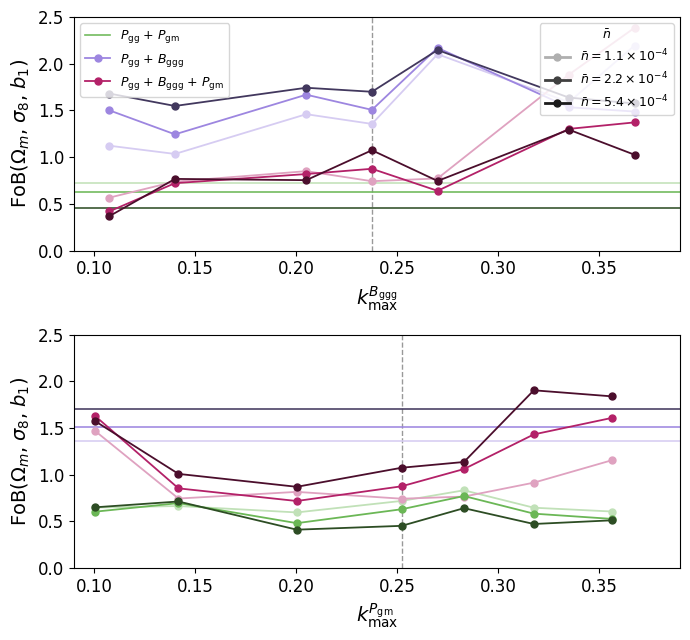

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig8_scale_dependence_fom3_full_nbars.png


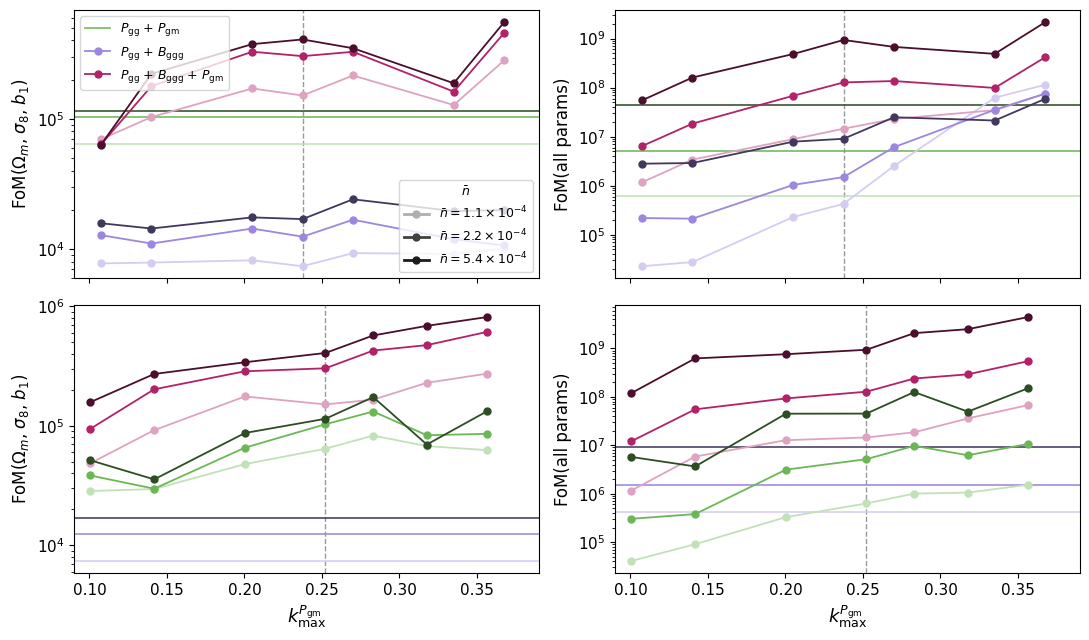

In [5]:
plot_scale_fob3_top(
    test_mode="shame",
    save_name="fig9_scale_dependence_fob3_nbars",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom_top(
    test_mode="shame",
    save_name="fig8_scale_dependence_fom3_full_nbars",
)


### shame — k=3 ensemble


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig16_scale_dependence_fob3_nbars_ensemble_shame.png


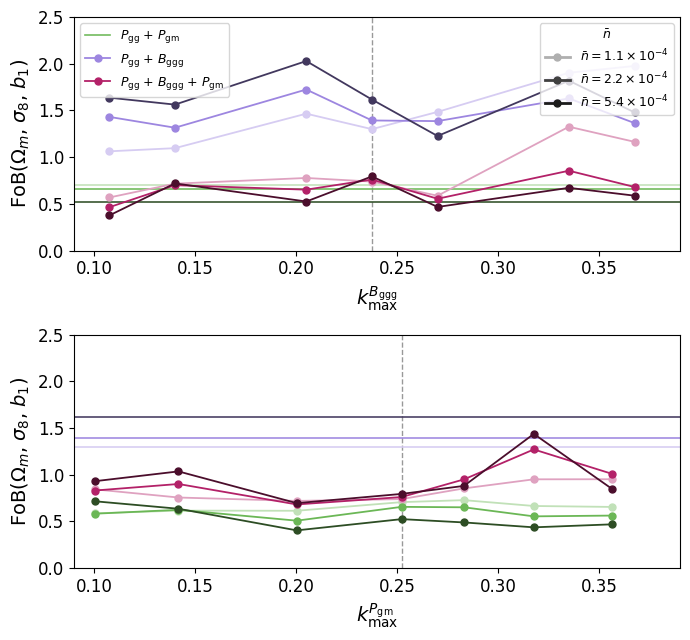

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig20_scale_dependence_fom3_full_nbars_ensemble_shame.png


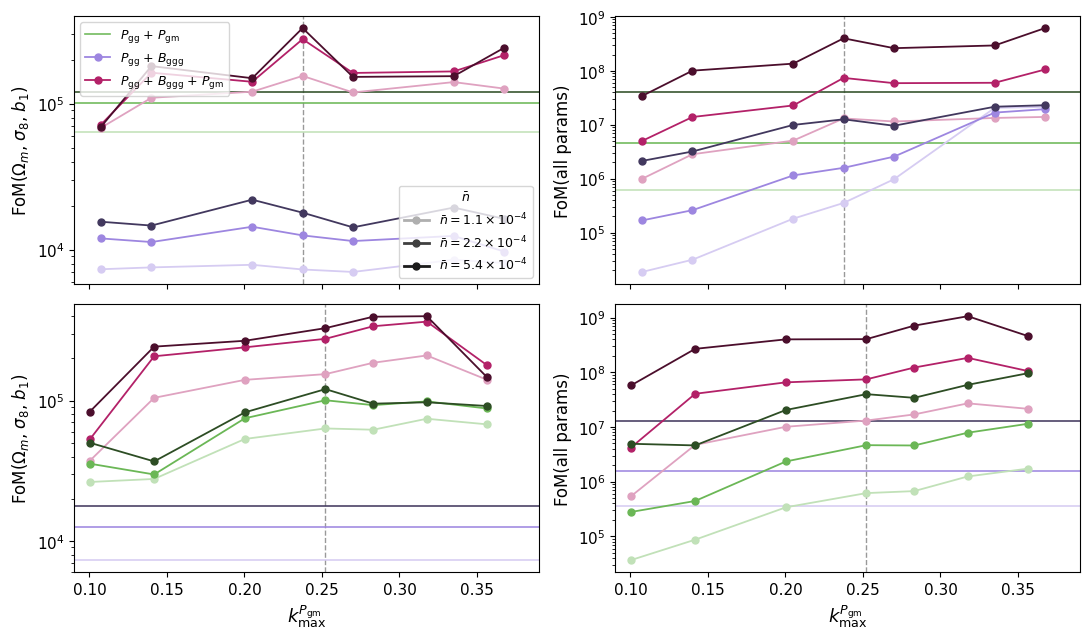

In [6]:
# SHAMe OOD — per-stat k_max sweeps (ensemble)
plot_scale_fob3_ensemble(
    test_mode="shame",
    save_name="fig16_scale_dependence_fob3_nbars_ensemble_shame",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom_ensemble(
    test_mode="shame",
    save_name="fig20_scale_dependence_fom3_full_nbars_ensemble_shame",
)


### cvmean — top model


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig9b_scale_dependence_fob3_cvmean.png


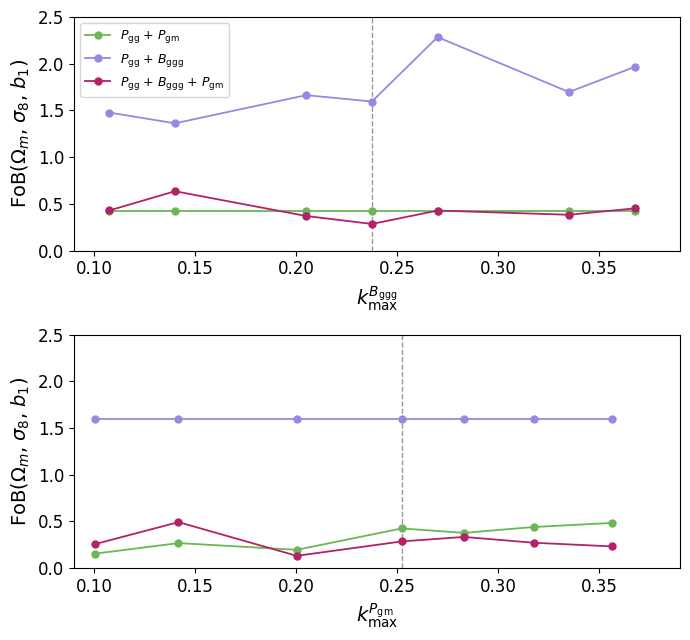

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig8b_scale_dependence_fom3_full_cvmean.png


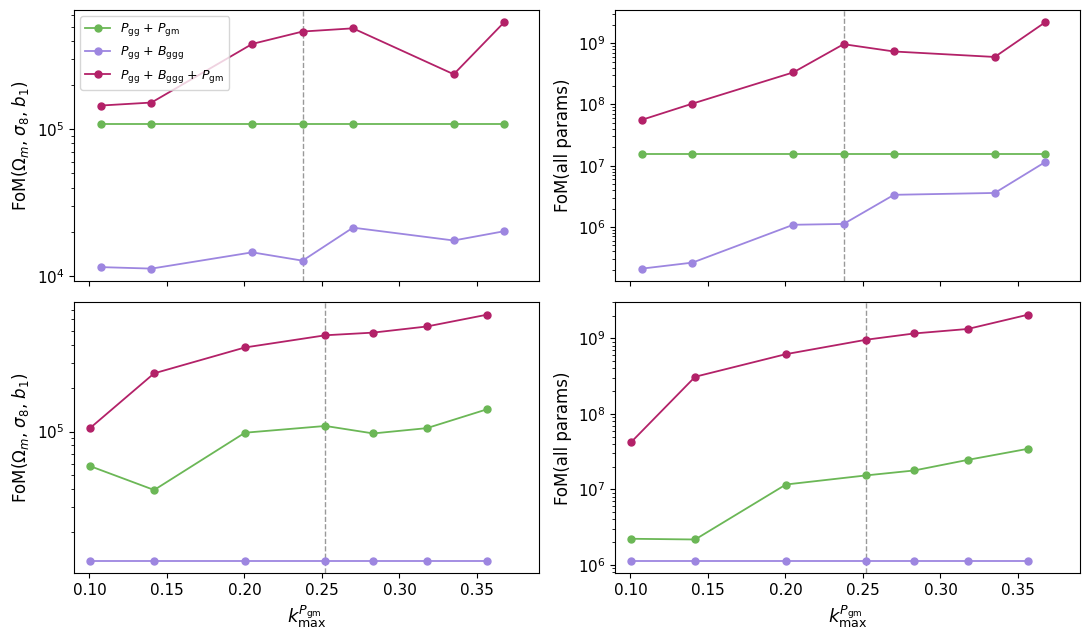

In [7]:
plot_scale_fob3_top(
    test_mode="cvmean",
    save_name="fig9b_scale_dependence_fob3_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom_top(
    test_mode="cvmean",
    save_name="fig8b_scale_dependence_fom3_full_cvmean",
)


### cvmean — k=3 ensemble


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig17_scale_dependence_fob3_nbars_ensemble_cvmean.png


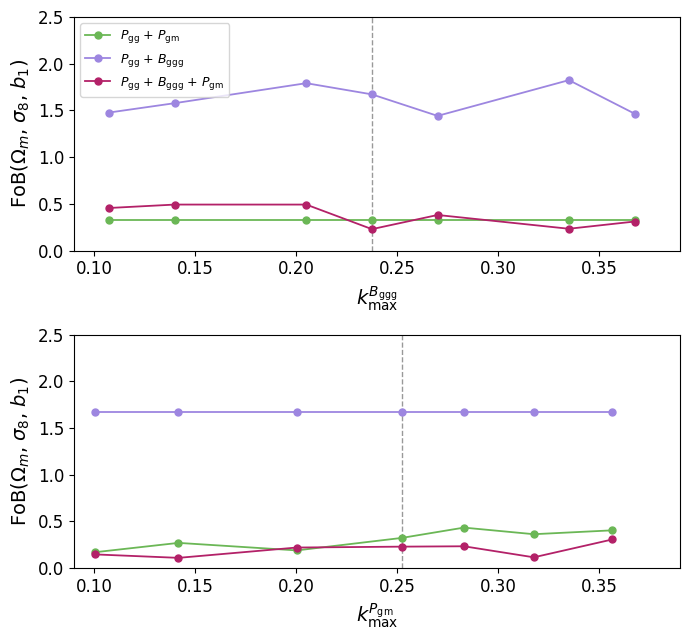

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig21_scale_dependence_fom3_full_nbars_ensemble_cvmean.png


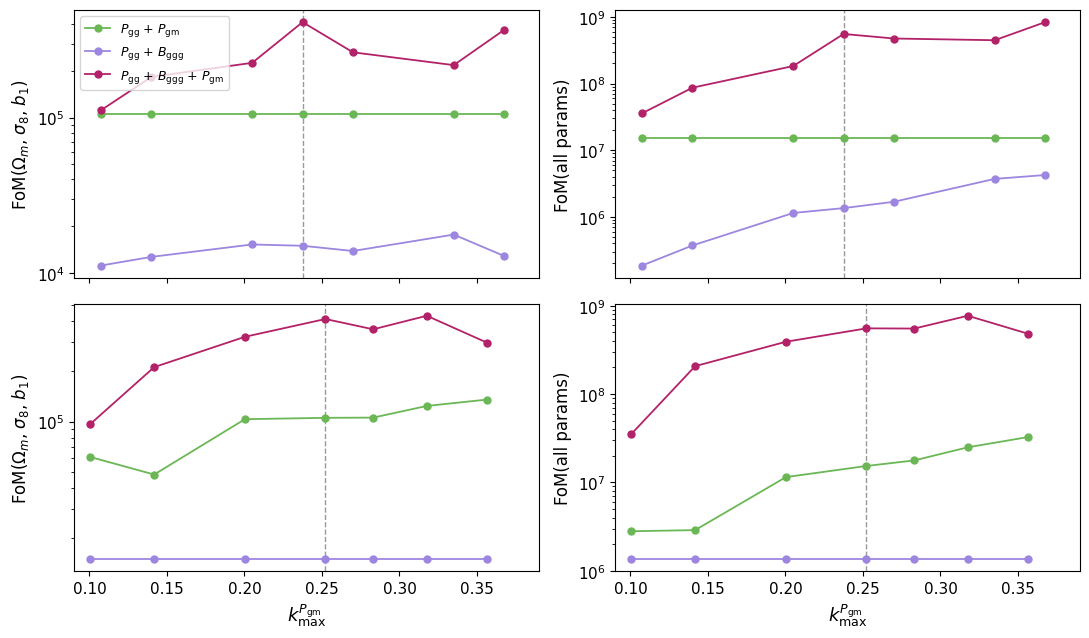

In [8]:
# CV-mean — per-stat k_max sweeps (ensemble)
plot_scale_fob3_ensemble(
    test_mode="cvmean",
    save_name="fig17_scale_dependence_fob3_nbars_ensemble_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom_ensemble(
    test_mode="cvmean",
    save_name="fig21_scale_dependence_fom3_full_nbars_ensemble_cvmean",
)


## kmax joint

Joint scale cut $k_{\mathrm{max}}$: all statistics use the same $k_{\mathrm{max}}$ when $k_{\mathrm{max}}\le 0.25$. For $k_{\mathrm{max}}>0.25$, $k_{\mathrm{max}}^{P_{\mathrm{gg}}}=k_{\mathrm{max}}$ while $k_{\mathrm{max}}^{B}=k_{\mathrm{max}}^{P_{\mathrm{gm}}}=0.25$ (i.e. $k_{\mathrm{max}}^{B}=k_{\mathrm{max}}^{P_{\mathrm{gm}}}=\min(k_{\mathrm{max}},0.25)$).


### shame — top model


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig10_scale_dependence_overall_kmax_fob_marg_nbars.png


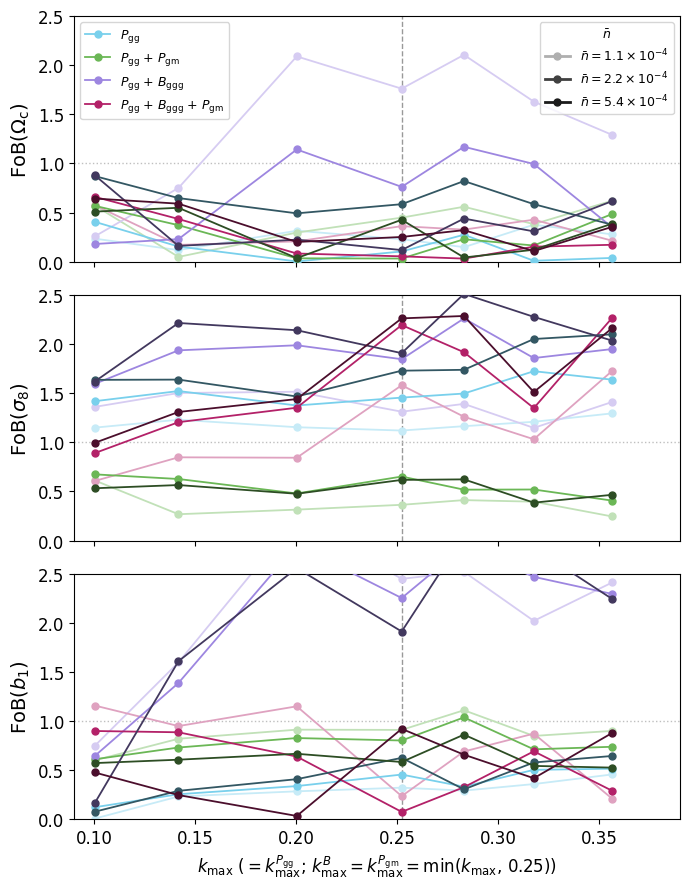

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig11_scale_dependence_overall_kmax_fom_marg_nbars.png


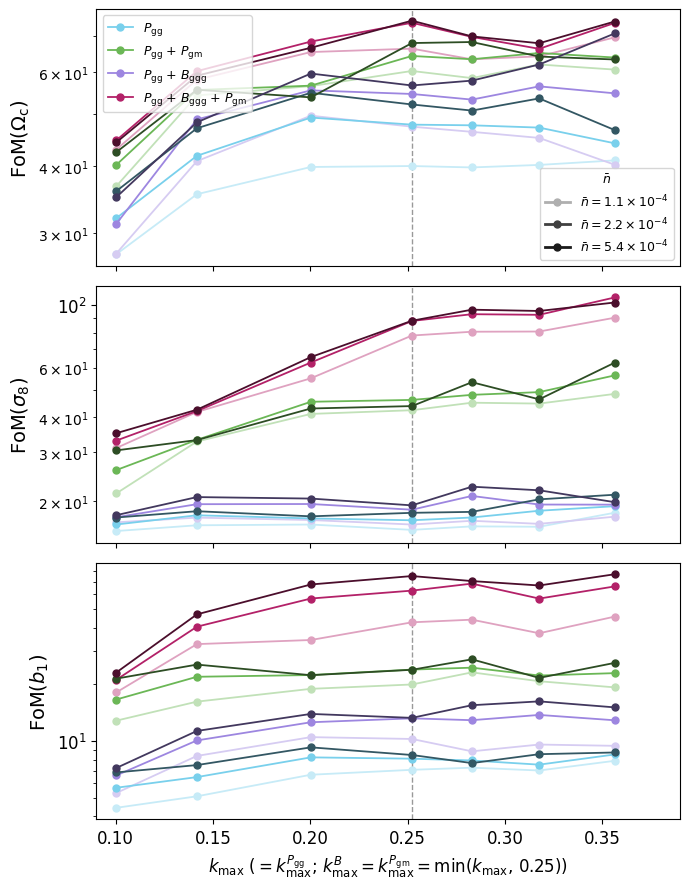

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig11b_scale_dependence_overall_kmax_fom3d_full_nbars.png


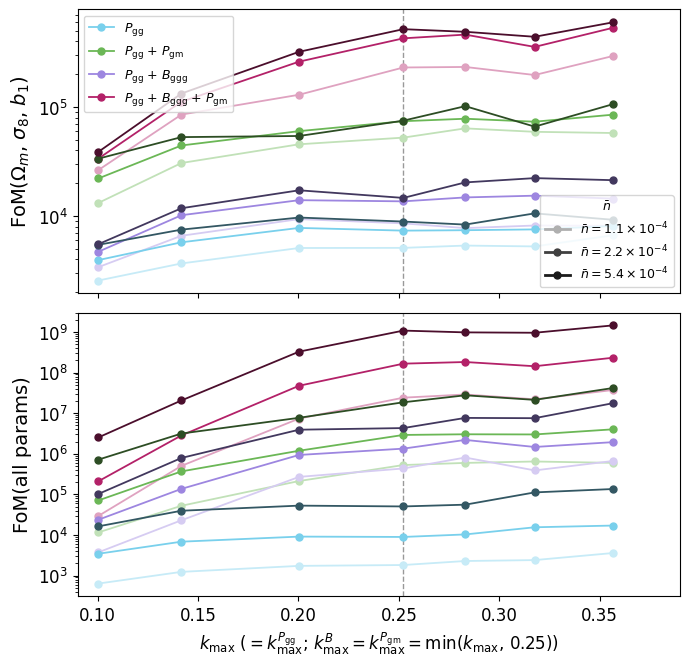

In [9]:
plot_scale_overall_kmax_fob3_shame_nbars(
    save_name="fig10_scale_dependence_overall_kmax_fob_marg_nbars",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
)
plot_scale_overall_kmax_fom3_shame_nbars(
    save_name="fig11_scale_dependence_overall_kmax_fom_marg_nbars",
)
plot_scale_overall_kmax_fom_joint(
    test_mode="shame",
    save_name="fig11b_scale_dependence_overall_kmax_fom3d_full_nbars",
)


### shame — k=3 ensemble


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig18_scale_dependence_overall_kmax_fob_marg_nbars_ensemble_shame.png


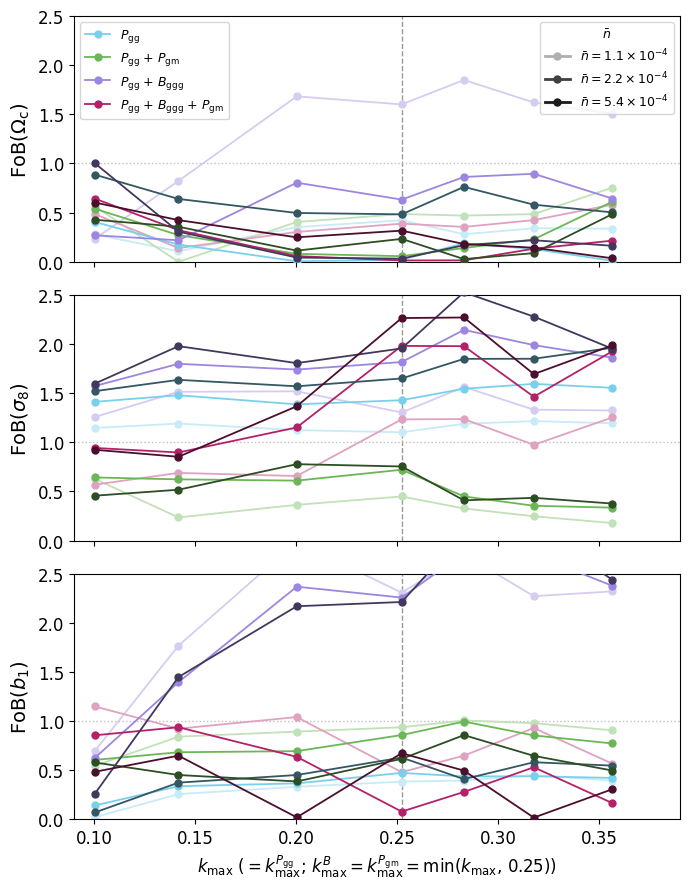

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig22_scale_dependence_overall_kmax_fom_marg_nbars_ensemble_shame.png


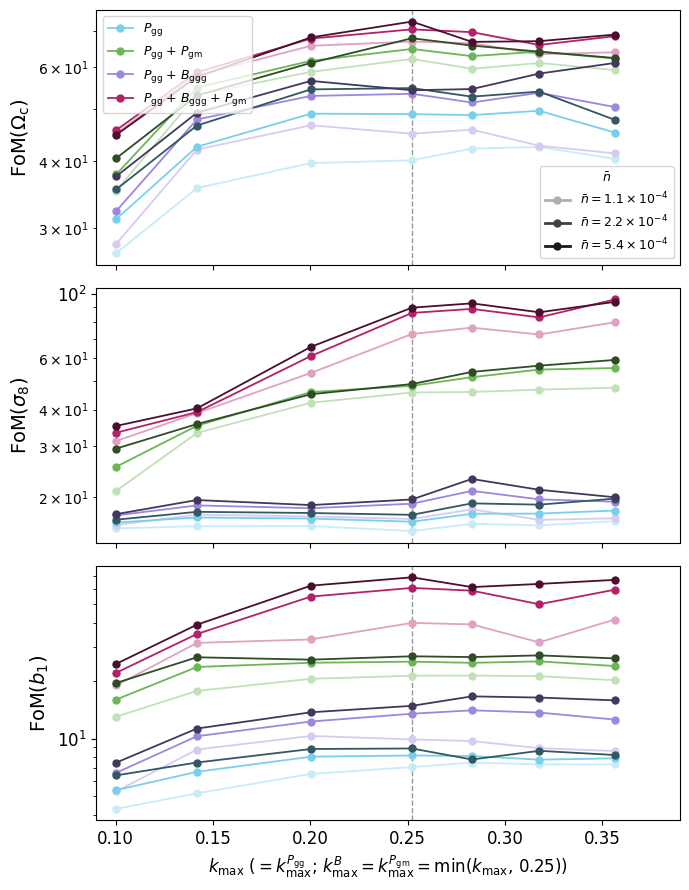

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig22b_scale_dependence_overall_kmax_fom3d_full_nbars_ensemble_shame.png


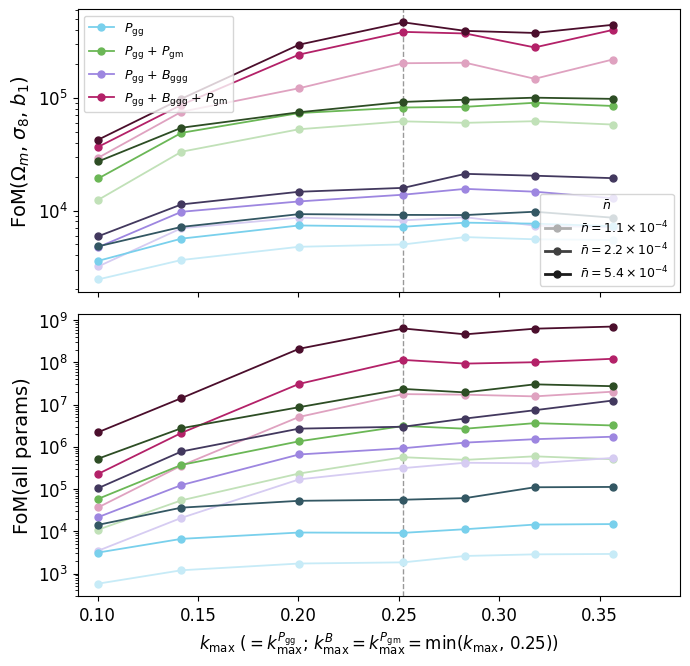

In [15]:
# SHAMe OOD — overall joint k_max (ensemble)
plot_scale_overall_kmax_fob3_ensemble(
    test_mode="shame",
    save_name="fig18_scale_dependence_overall_kmax_fob_marg_nbars_ensemble_shame",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
)
plot_scale_overall_kmax_fom3_ensemble(
    test_mode="shame",
    save_name="fig22_scale_dependence_overall_kmax_fom_marg_nbars_ensemble_shame",
)
plot_scale_overall_kmax_fom_joint_ensemble(
    test_mode="shame",
    save_name="fig22b_scale_dependence_overall_kmax_fom3d_full_nbars_ensemble_shame",
)


### cvmean — top model


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig14_scale_dependence_overall_kmax_fob_marg_cvmean.png


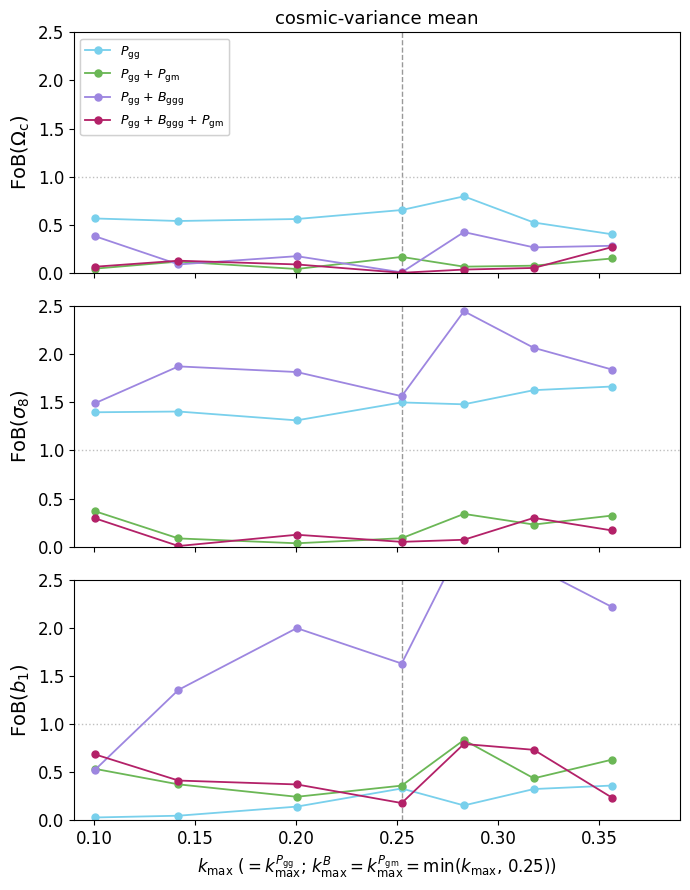

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig15_scale_dependence_overall_kmax_fom_marg_cvmean.png


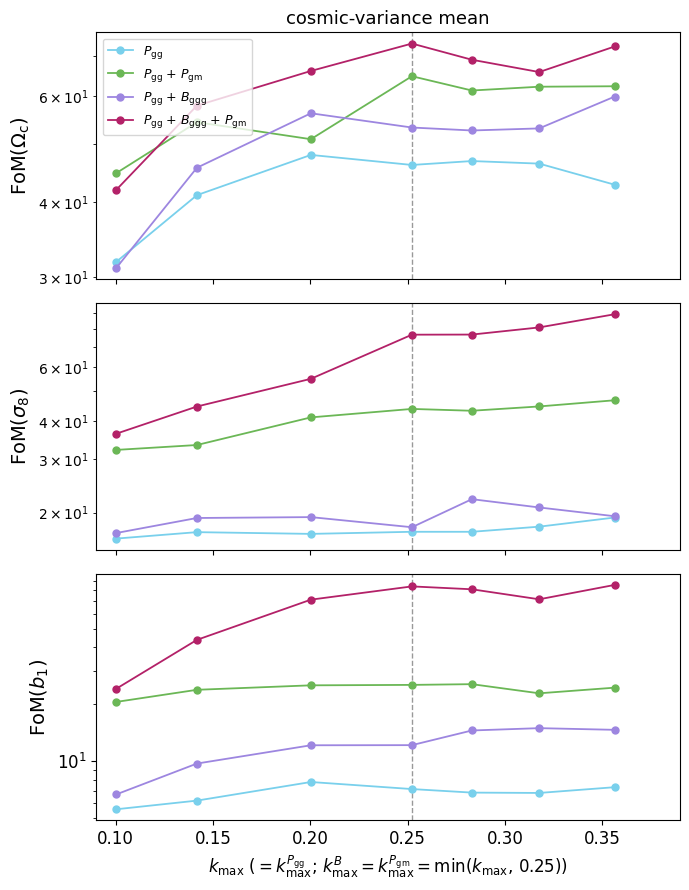

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig15b_scale_dependence_overall_kmax_fom3d_full_cvmean.png


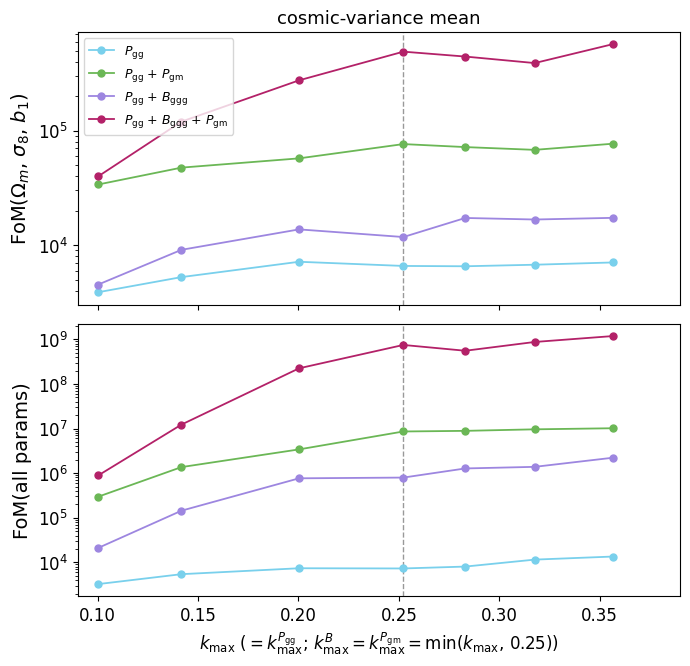

In [16]:
plot_scale_overall_kmax_fob3(
    test_mode="cvmean",
    save_name="fig14_scale_dependence_overall_kmax_fob_marg_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
)
plot_scale_overall_kmax_fom3(
    test_mode="cvmean",
    save_name="fig15_scale_dependence_overall_kmax_fom_marg_cvmean",
)
plot_scale_overall_kmax_fom_joint(
    test_mode="cvmean",
    save_name="fig15b_scale_dependence_overall_kmax_fom3d_full_cvmean",
)


### cvmean — k=3 ensemble


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig19_scale_dependence_overall_kmax_fob_marg_ensemble_cvmean.png


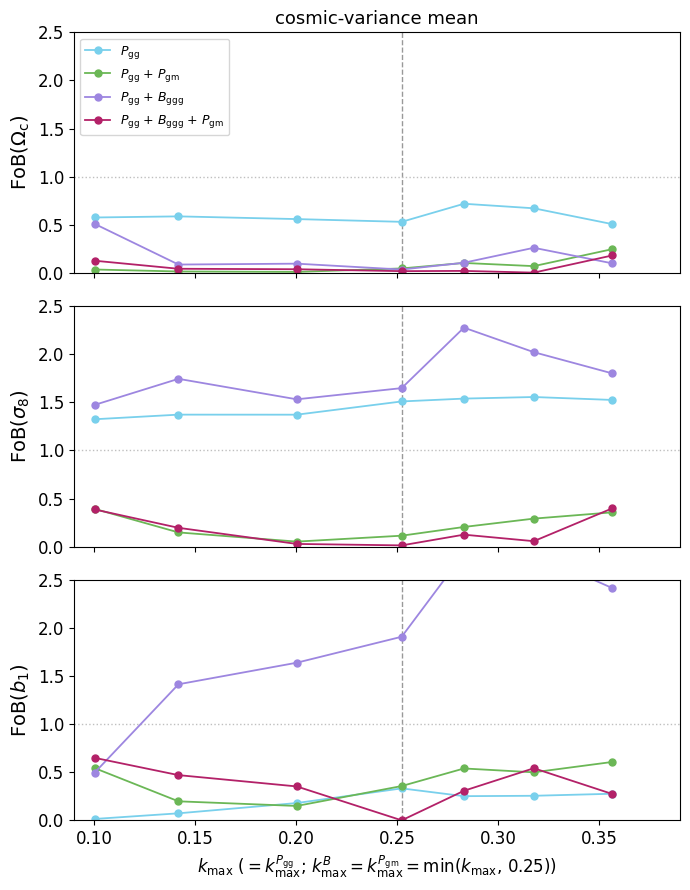

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig23_scale_dependence_overall_kmax_fom_marg_ensemble_cvmean.png


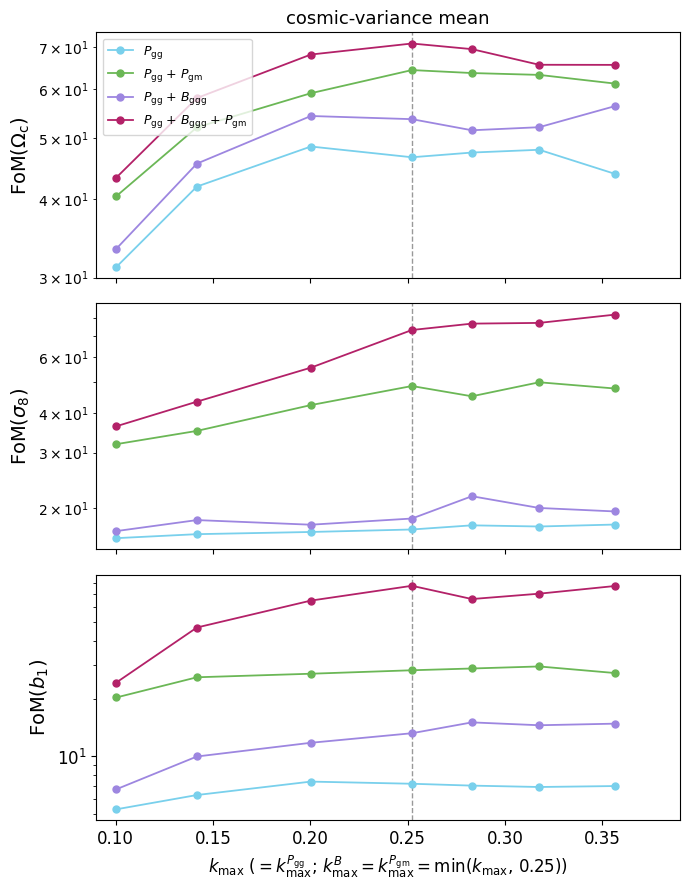

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig23b_scale_dependence_overall_kmax_fom3d_full_ensemble_cvmean.png


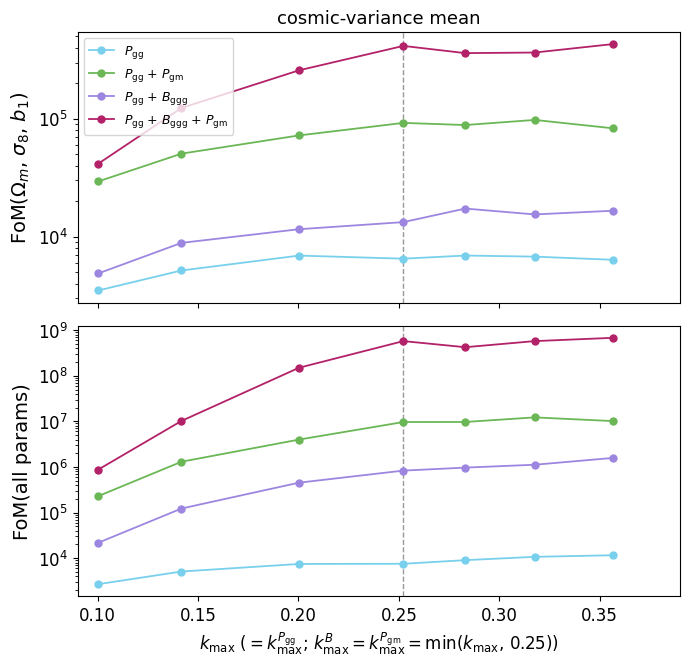

In [17]:
# CV-mean — overall joint k_max (ensemble)
plot_scale_overall_kmax_fob3_ensemble(
    test_mode="cvmean",
    save_name="fig19_scale_dependence_overall_kmax_fob_marg_ensemble_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
)
plot_scale_overall_kmax_fom3_ensemble(
    test_mode="cvmean",
    save_name="fig23_scale_dependence_overall_kmax_fom_marg_ensemble_cvmean",
)
plot_scale_overall_kmax_fom_joint_ensemble(
    test_mode="cvmean",
    save_name="fig23b_scale_dependence_overall_kmax_fom3d_full_ensemble_cvmean",
)


## kmax contours


### shame, kmax joint

SHAMe OOD contours vs joint $k_{\mathrm{max}}$ (shared cut if $\le 0.25$; else $k_{\mathrm{max}}^{B}=k_{\mathrm{max}}^{P_{\mathrm{gm}}}=0.25$).


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.15_kb0.15_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.15_kb0.15_kpgm0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.2_kb0.2_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.2_kb0.2_kpgm0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.25_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit

/tmp/ipykernel_234526/416603309.py:1439: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig12_overall_kmax_contours_full_combo_nbar0.00022.png


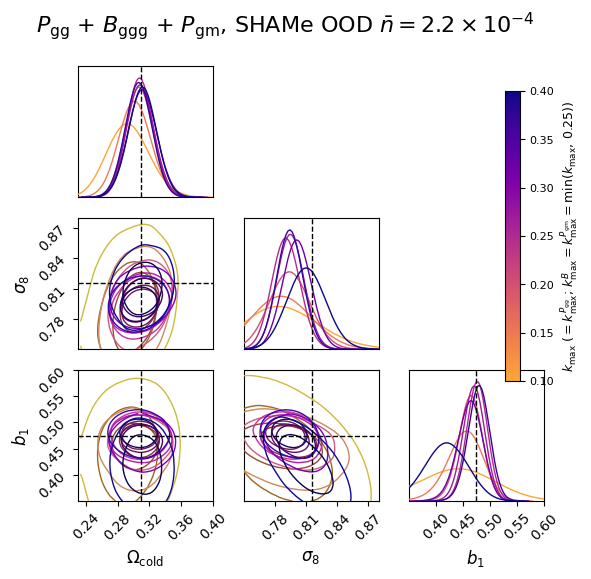

In [18]:
plot_overall_kmax_contours_full_combo(
    tag_mock=TAG_MOCK_SHAME,
    save_name="fig12_overall_kmax_contours_full_combo_nbar0.00022",
)


### cv, kmax joint

CV-mean contours vs joint $k_{\mathrm{max}}$ (shared cut if $\le 0.25$; else $k_{\mathrm{max}}^{B}=k_{\mathrm{max}}^{P_{\mathrm{gm}}}=0.25$).


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.15_kb0.15_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.15_kb0.15_kpgm0.15_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.2_kb0.2_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.2_kb0.2_kpgm0.2_shame_p0_n1000_biasshame_noisebest_p0_n1_no

/tmp/ipykernel_234526/416603309.py:1439: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig13_overall_kmax_contours_full_combo_cvmean.png


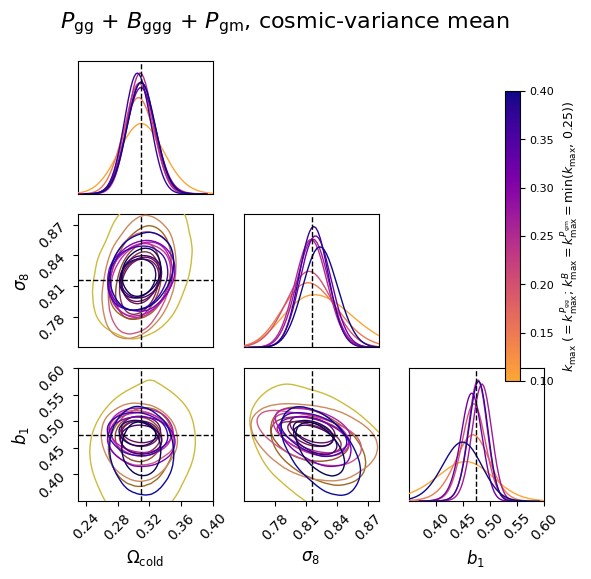

In [19]:
plot_overall_kmax_contours_full_combo(
    test_mode="cvmean",
    save_name="fig13_overall_kmax_contours_full_combo_cvmean",
)


## Contours at $k_{\mathrm{max}}^{P_{gg}}=0.35$ ($k_{\mathrm{max}}^{B}=k_{\mathrm{max}}^{P_{gm}}=0.25$)

Same multi-stat overlay style as the fiducial CV / SHAMe contours ($\Omega_{\mathrm{c}}$, $\sigma_8$, $\sigma_8 b_1$), using the dedicated kp0.35 / kb0.25 / kpgm0.25 models.

Order: **top model** (SHAMe, then CV), then **$k{=}3$ ensemble** (SHAMe, then CV).


### Top model — SHAMe


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.35_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kp0.35_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kp0.35_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.

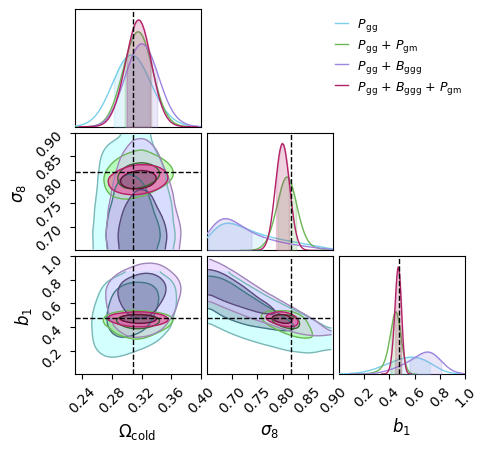

In [20]:
plot_kp035_contours_top(
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    save_name="fig_kp035_contours_top_shame_nbar0.00022",
)


### Top model — CV mean


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/result

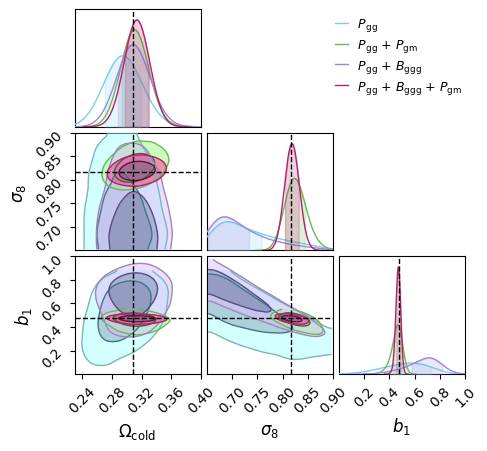

In [21]:
plot_kp035_contours_top(
    test_mode="cvmean",
    save_name="fig_kp035_contours_top_cvmean",
)


### Ensemble ($k=3$) — SHAMe


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig_kp035_contours_ensemble_shame_nbar0.00022.png


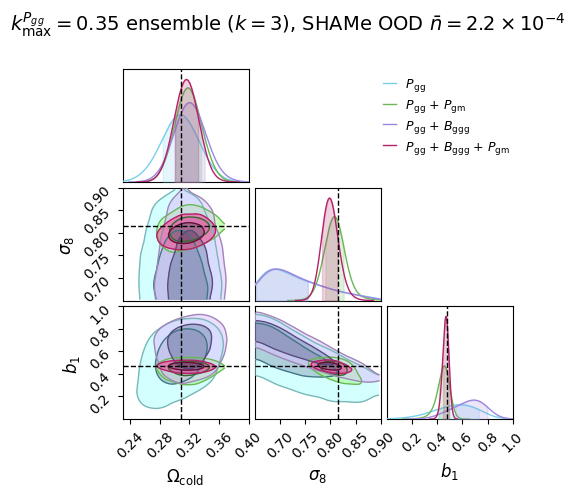

In [22]:
plot_kp035_contours_ensemble(
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    save_name="fig_kp035_contours_ensemble_shame_nbar0.00022",
)


### Ensemble ($k=3$) — CV mean


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig_kp035_contours_ensemble_cvmean.png


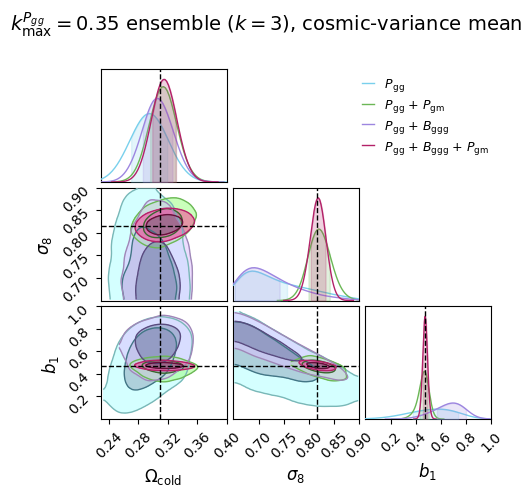

In [23]:
plot_kp035_contours_ensemble(
    test_mode="cvmean",
    save_name="fig_kp035_contours_ensemble_cvmean",
)


## Top-5 by $\ell_\mathrm{val}$ + ensemble ($k{=}3$) at $k_\mathrm{max}^{P_{gg}}=0.35$

Full combo $P_{gg}+B+P_{gm}$ at `_kp0.35_kb0.25_kpgm0.25`. Contours for the top stall-passing models (colored by $\ell_\mathrm{val}$) plus an equal-weight mixture of the top $k{=}3$ — same style as `2026-06-04_sweep_top5_ensemble_shame`.


### SHAMe OOD


Missing 2/5 top-N members (shame):
  nbest3 (v9zij2h0): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest3/samples_test_shame_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_nbar0.00022_pred.npy
  nbest4 (j4n2j4rd): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest4/samples_test_shame_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_nbar0.00022_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig_kp035_top5_lval_ensemble_shame_nbar0.00022.png
ℓ_val range: [-5.666, -4.934]  (best=kt4wum40; plotted 3/5)


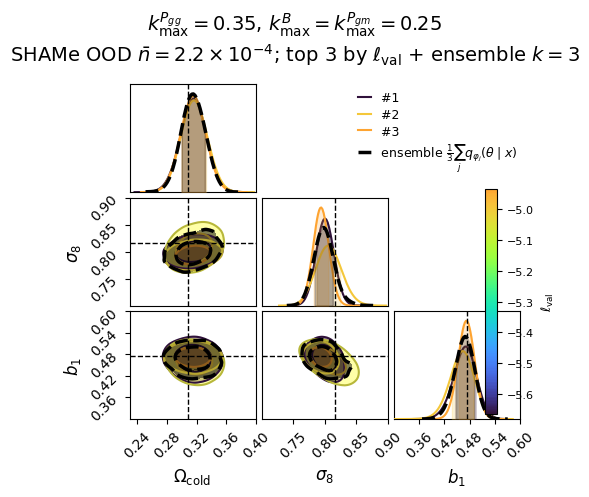

In [24]:
plot_kp035_topn_loss_contours(
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    save_name="fig_kp035_top5_lval_ensemble_shame_nbar0.00022",
)


### CV mean


Missing 2/5 top-N members (cvmean):
  nbest3 (v9zij2h0): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest3/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
  nbest4 (j4n2j4rd): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest4/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig_kp035_top5_lval_ensemble_cvmean.png
ℓ_val range: [-5.666, -4.934]  (best=kt4wum40; plotted 3/5)


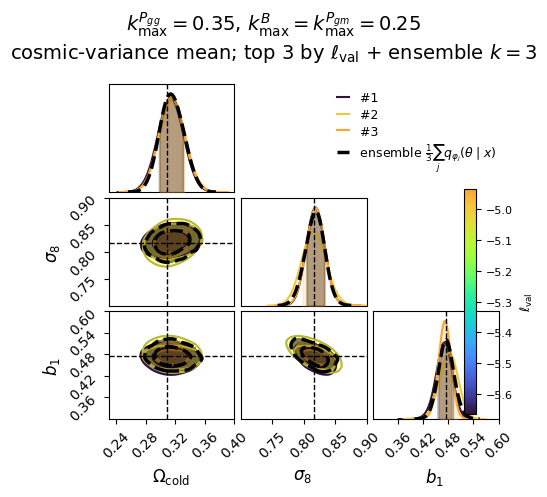

In [25]:
plot_kp035_topn_loss_contours(
    test_mode="cvmean",
    save_name="fig_kp035_top5_lval_ensemble_cvmean",
)


## Precision gain: overall $k_\mathrm{max}$

Compare SHAMe OOD and CV-mean on physical $(\Omega_\mathrm{c},\sigma_8,b_1)$.

- `metric="fom"` — marginal FoM $=1/\sigma$ (same as overall FoM panels); $\Delta\%=100(\mathrm{FoM}_{hi}/\mathrm{FoM}_{lo}-1)$.
- `metric="err"` — paper symmetrized width $\mathrm{err}=\tfrac12(p_{84}-p_{16})$; $\Delta\%=100(\mathrm{err}_{lo}/\mathrm{err}_{hi}-1)$.

Joint overall cut: for $k>0.25$, $k_\mathrm{max}^{P_\mathrm{gg}}=k$ with $B$ and $P_\mathrm{gm}$ capped at $0.25$.


In [26]:
def print_precision_gain_table(
    k_lo,
    k_hi,
    *,
    metric="fom",
    tag_mock=TAG_MOCK_SHAME,
):
    """Print precision gain from overall k_max=k_lo → k_hi.

    Parameters
    ----------
    k_lo, k_hi : float
        Overall joint k_max endpoints (via ``overall_k_mask``).
    metric : {"fom", "err"}
        ``"fom"`` — FoM = 1/σ (same as overall FoM panels);
        Δ% = 100*(FoM_hi/FoM_lo − 1).
        ``"err"`` — symmetrized 68% width err = ½(p84 − p16) after
        unreparameterization (paper PrecPct);
        Δ% = 100*(err_lo/err_hi − 1).
    tag_mock : str
        SHAMe OOD mock tag (default ``TAG_MOCK_SHAME``).
    """
    metric = str(metric).lower()
    if metric not in ("fom", "err"):
        raise ValueError(f'metric must be "fom" or "err", got {metric!r}')

    param_labels = {
        "omega_cold": "Omegac",
        "sigma8_cold": "sigma8",
        "b1": "b1",
    }
    param_labs = ("Omegac", "sigma8", "b1")
    datasets = [
        ("SHAMe", "shame", tag_mock),
        ("CV-mean", "cvmean", tag_mock),
    ]

    def _combo_plain(statistics_row):
        return (
            get_stat_label_short(statistics_row)
            .replace(r"$P_\mathrm{gg}$", "Pgg")
            .replace(r"$B_\mathrm{ggg}$", "Bggg")
            .replace(r"$P_\mathrm{gm}$", "Pgm")
            .replace(" + ", "+")
        )

    def _symmetrized_68_err(samples_1d):
        p16, p84 = np.percentile(samples_1d, [16.0, 84.0])
        return 0.5 * (float(p84) - float(p16))

    def _values(statistics_row, k, *, test_mode, tag_mock):
        tag_mask = overall_k_mask(statistics_row, k)
        if metric == "fom":
            out = {}
            for pn in PARAM_NAMES_FOM:
                val, reason = load_overall_kmax_fom_marg(
                    statistics_row, tag_mask, pn,
                    test_mode=test_mode, tag_mock=tag_mock,
                )
                if val is None:
                    raise FileNotFoundError(reason)
                out[pn] = float(val)
            return out

        samples, param_names, reason = _overall_kmax_samples_path(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if samples is None:
            raise FileNotFoundError(reason)
        samp = np.asarray(samples)
        if samp.ndim == 2:
            samp = samp[:, np.newaxis, :]
        samp = samp[:, idx_obs, :]
        samp, names = ui.unreparameterize_theta(samp, param_names)
        names = list(names)
        return {
            pn: _symmetrized_68_err(samp[:, names.index(pn)])
            for pn in PARAM_NAMES_FOM
        }

    by_key = {}
    for statistics_row in STATISTICS_ARR_FID:
        combo = _combo_plain(statistics_row)
        for ds_name, test_mode, tag_mock_ds in datasets:
            v_lo = _values(statistics_row, k_lo, test_mode=test_mode, tag_mock=tag_mock_ds)
            v_hi = _values(statistics_row, k_hi, test_mode=test_mode, tag_mock=tag_mock_ds)
            cells = {}
            for pn in PARAM_NAMES_FOM:
                lo, hi = v_lo[pn], v_hi[pn]
                if metric == "fom":
                    dprec = 100.0 * (hi / lo - 1.0)
                else:
                    dprec = 100.0 * (lo / hi - 1.0)
                cells[param_labels[pn]] = (lo, hi, dprec)
            by_key[(combo, ds_name)] = cells

    lo_s, hi_s = f"{k_lo:g}", f"{k_hi:g}"
    metric_name = "FoM" if metric == "fom" else "err"
    if metric == "fom":
        delta_desc = f"d% = 100*(FoM_{hi_s}/FoM_{lo_s} - 1)"
    else:
        delta_desc = f"d% = 100*(err_{lo_s}/err_{hi_s} - 1)"

    header = (
        f"{'Combo':14s} {'Dataset':8s} "
        f"{'Oc@'+lo_s:>9s} {'Oc@'+hi_s:>9s} {'Oc d%':>8s} "
        f"{'s8@'+lo_s:>9s} {'s8@'+hi_s:>9s} {'s8 d%':>8s} "
        f"{'b1@'+lo_s:>9s} {'b1@'+hi_s:>9s} {'b1 d%':>8s}"
    )
    print(f"Precision gain ({metric_name}): overall k_max {lo_s} -> {hi_s}")
    print(f"{delta_desc}; SHAMe tag_mock={tag_mock}")
    print(
        "At k>0.25: Pk uses k; B and Pgm stay at 0.25 "
        f"(masks: {overall_k_mask(['pk', 'bispec', 'pgm'], k_lo)} -> "
        f"{overall_k_mask(['pk', 'bispec', 'pgm'], k_hi)}; "
        f"plot x_pk: {kmax_plot_x_pk(k_lo):.3f} -> {kmax_plot_x_pk(k_hi):.3f})"
    )
    print(header)
    print("-" * len(header))

    for statistics_row in STATISTICS_ARR_FID:
        combo = _combo_plain(statistics_row)
        for ds_name, _, _ in datasets:
            cells = by_key[(combo, ds_name)]
            parts = [f"{combo:14s}", f"{ds_name:8s}"]
            for lab in param_labs:
                lo, hi, dp = cells[lab]
                parts.append(f"{lo:9.4g}")
                parts.append(f"{hi:9.4g}")
                parts.append(f"{dp:+7.1f}%")
            print(" ".join(parts))

    print()
    print(
        f"{'Combo':14s} {'SHAMe Oc':>9s} {'SHAMe s8':>9s} {'SHAMe b1':>9s} "
        f"{'CV Oc':>9s} {'CV s8':>9s} {'CV b1':>9s}"
    )
    print("-" * 72)
    for statistics_row in STATISTICS_ARR_FID:
        combo = _combo_plain(statistics_row)
        shame = by_key[(combo, "SHAMe")]
        cv = by_key[(combo, "CV-mean")]
        print(
            f"{combo:14s} "
            f"{shame['Omegac'][2]:+8.1f}% {shame['sigma8'][2]:+8.1f}% {shame['b1'][2]:+8.1f}% "
            f"{cv['Omegac'][2]:+8.1f}% {cv['sigma8'][2]:+8.1f}% {cv['b1'][2]:+8.1f}%"
        )


In [27]:
# FoM (matches overall FoM panels; K_OVERALL last point = 0.37)
print_precision_gain_table(0.25, 0.37, metric="fom")


Precision gain (FoM): overall k_max 0.25 -> 0.37
d% = 100*(FoM_0.37/FoM_0.25 - 1); SHAMe tag_mock=_nbar0.00022
At k>0.25: Pk uses k; B and Pgm stay at 0.25 (masks: _kp0.25_kb0.25_kpgm0.25 -> _kp0.37_kb0.25_kpgm0.25; plot x_pk: 0.252 -> 0.356)
Combo          Dataset    Oc@0.25   Oc@0.37    Oc d%   s8@0.25   s8@0.37    s8 d%   b1@0.25   b1@0.37    b1 d%
--------------------------------------------------------------------------------------------------------------
Pgg            SHAMe        47.82     44.13    -7.7%     17.09     19.19   +12.3%     8.091     8.517    +5.3%
Pgg            CV-mean      46.11     42.74    -7.3%     17.31     19.27   +11.4%     7.133     7.298    +2.3%
Pgg+Pgm        SHAMe         64.3     63.86    -0.7%     45.98     56.25   +22.3%     23.97     22.96    -4.2%
Pgg+Pgm        CV-mean      64.85      62.4    -3.8%     43.73     46.68    +6.8%     25.33     24.49    -3.3%
Pgg+Bggg       SHAMe        54.58     54.74    +0.3%     18.64     19.43    +4.2%     13.23

In [28]:
# Symmetrized-err / paper PrecPct
print_precision_gain_table(0.25, 0.37, metric="err")

Precision gain (err): overall k_max 0.25 -> 0.37
d% = 100*(err_0.25/err_0.37 - 1); SHAMe tag_mock=_nbar0.00022
At k>0.25: Pk uses k; B and Pgm stay at 0.25 (masks: _kp0.25_kb0.25_kpgm0.25 -> _kp0.37_kb0.25_kpgm0.25; plot x_pk: 0.252 -> 0.356)
Combo          Dataset    Oc@0.25   Oc@0.37    Oc d%   s8@0.25   s8@0.37    s8 d%   b1@0.25   b1@0.37    b1 d%
--------------------------------------------------------------------------------------------------------------
Pgg            SHAMe      0.02064   0.02213    -6.7%   0.06212    0.0524   +18.6%    0.1528    0.1409    +8.4%
Pgg            CV-mean    0.02163   0.02287    -5.4%   0.06055   0.05298   +14.3%    0.1639    0.1582    +3.6%
Pgg+Pgm        SHAMe      0.01549   0.01564    -0.9%    0.0186   0.01512   +23.0%   0.04026   0.03781    +6.5%
Pgg+Pgm        CV-mean    0.01522   0.01602    -5.0%   0.02247    0.0211    +6.5%   0.04456   0.03969   +12.3%
Pgg+Bggg       SHAMe      0.01835   0.01816    +1.1%    0.0525   0.05071    +3.5%     0.114